# OLST Balance Classification — Full Pipeline
### One-leg stance test (OLST): STABLE vs UNSTABLE detection
**Pipeline order:**
1. Load & rename variables
2. Exploratory data analysis (EDA)
3. Statistical testing (Mann-Whitney U + FDR)
4. Correlation analysis
5. **ML — ALL features** (LOSO, single & multi-modality)
6. **PCA feature reduction** + ML (LOSO)
7. **Top-N important features** selection + ML (LOSO)
8. Comparison: All features vs PCA vs Important features


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, f1_score, balanced_accuracy_score,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

%matplotlib inline
print("Imports OK")


Imports OK


## 1 · Load & rename variables

In [3]:
df_raw = pd.read_csv('data/OLST_Final_Cleaned.csv')

rename_map = {
    # ── Metadata / identifiers
    'OLST_attempt_id':      'OLST_attempt_id',
    'RADAR_capture':        'RDAR_capture',
    'participant_id':       'participant_id',
    'label':                'label',
    'movement_code':        'movement_code',
    'stance_leg':           'stance_leg',
    'lifted_leg':           'lifted_leg',
    'an':                   'an',
    'is_attempt_final':     'is_attempt_final',

    # ── Timing / frame metadata
    'MOCAP_Start_Time':     'MCAP_Start_Time',
    'MOCAP_End_Time':       'MCAP_End_Time',
    'RADAR_Start_Frame':    'RDAR_Start_Frame',
    'RADAR_End_Frame':      'RDAR_End_Frame',
    'Seconds_per_Frame':    'Seconds_per_Frame',
    't_foot_up':            't_foot_up',
    't_stable':             't_stable',
    't_break':              't_break',
    't_end':                't_end',
    'frame_foot_up':        'frame_foot_up',
    'frame_stable':         'frame_stable',
    'frame_break':          'frame_break',
    'frame_end':            'frame_end',
    'trial_duration_s':     'trial_duration_s',

    # ── MOCAP features
    'stance_knee_vel_mean':   'MOCAP_stance_knee_vel_mean',
    'stance_knee_vel_std':    'MOCAP_stance_knee_vel_std',
    'stance_knee_vel_max':    'MOCAP_stance_knee_vel_max',
    'lifted_knee_vel_mean':   'MOCAP_lifted_knee_vel_mean',
    'lifted_knee_vel_std':    'MOCAP_lifted_knee_vel_std',
    'lifted_knee_vel_max':    'MOCAP_lifted_knee_vel_max',
    'stance_knee_acc_mean':   'MOCAP_stance_knee_acc_mean',
    'stance_knee_acc_std':    'MOCAP_stance_knee_acc_std',
    'stance_knee_acc_max':    'MOCAP_stance_knee_acc_max',
    'lifted_knee_acc_mean':   'MOCAP_lifted_knee_acc_mean',
    'lifted_knee_acc_std':    'MOCAP_lifted_knee_acc_std',
    'lifted_knee_acc_max':    'MOCAP_lifted_knee_acc_max',
    'com_disp_mean':          'MOCAP_com_disp_mean',
    'com_disp_std':           'MOCAP_com_disp_std',
    'com_disp_max':           'MOCAP_com_disp_max',
    'com_range_x':            'MOCAP_com_range_x',
    'com_range_y':            'MOCAP_com_range_y',
    'com_vel_mean':           'MOCAP_com_vel_mean',
    'com_vel_std':            'MOCAP_com_vel_std',
    'trunk_sway_x_std':       'MOCAP_trunk_sway_x_std',
    'trunk_sway_y_std':       'MOCAP_trunk_sway_y_std',
    'trunk_sway_x_range':     'MOCAP_trunk_sway_x_range',
    'trunk_sway_y_range':     'MOCAP_trunk_sway_y_range',
    'trunk_sway_vel_mean':    'MOCAP_trunk_sway_vel_mean',
    'trunk_sway_vel_std':     'MOCAP_trunk_sway_vel_std',

    # ── Radar features
    'doppler_centroid_mean':  'RADAR_doppler_centroid_mean',
    'doppler_centroid_std':   'RADAR_doppler_centroid_std',
    'doppler_centroid_max':   'RADAR_doppler_centroid_max',
    'doppler_centroid_range': 'RADAR_doppler_centroid_range',
    'micro_vel_mean':         'RADAR_micro_vel_mean',
    'micro_vel_std':          'RADAR_micro_vel_std',
    'micro_vel_max':          'RADAR_micro_vel_max',
    'micro_vel_energy':       'RADAR_micro_vel_energy',
    'micro_acc_mean':         'RADAR_micro_acc_mean',
    'micro_acc_std':          'RADAR_micro_acc_std',
    'micro_acc_max':          'RADAR_micro_acc_max',
    'amp_total_power_mean':   'RADAR_amp_total_power_mean',
    'amp_total_power_std':    'RADAR_amp_total_power_std',
    'amp_total_power_range':  'RADAR_amp_total_power_range',
    'amp_peak_power_mean':    'RADAR_amp_peak_power_mean',
    'amp_peak_power_std':     'RADAR_amp_peak_power_std',
    'amp_variation_mean':     'RADAR_amp_variation_mean',
    'amp_variation_std':      'RADAR_amp_variation_std',
    'amp_variation_max':      'RADAR_amp_variation_max',

    # ── ForcePlate features
    'COP_AP_range_mm':              'ForcePlate_COP_AP_range_mm',
    'COP_AP_mean_mm':               'ForcePlate_COP_AP_mean_mm',
    'COP_AP_sd_mm':                 'ForcePlate_COP_AP_sd_mm',
    'COP_ML_range_mm':              'ForcePlate_COP_ML_range_mm',
    'COP_ML_mean_mm':               'ForcePlate_COP_ML_mean_mm',
    'COP_ML_sd_mm':                 'ForcePlate_COP_ML_sd_mm',
    'COP_speed_mean_mm_s':          'ForcePlate_COP_speed_mean_mm_s',
    'COP_speed_sd_mm_s':            'ForcePlate_COP_speed_sd_mm_s',
    'COP_speed_max_mm_s':           'ForcePlate_COP_speed_max_mm_s',
    'COP_speed_computed_mean':      'ForcePlate_COP_speed_computed_mean',
    'GRF_Z_mean_N':                 'ForcePlate_GRF_Z_mean_N',
    'GRF_Z_sd_N':                   'ForcePlate_GRF_Z_sd_N',
    'GRF_Z_cv_pct':                 'ForcePlate_GRF_Z_cv_pct',
    'GRF_Z_range_N':                'ForcePlate_GRF_Z_range_N',
    'sway_path_length_mm':          'ForcePlate_sway_path_length_mm',
    'sway_path_per_second_mm_s':    'ForcePlate_sway_path_per_second_mm_s',
}

df = df_raw.rename(columns=rename_map)

# Feature group columns
MOCAP_cols      = [c for c in df.columns if c.startswith('MOCAP_')]
RADAR_cols      = [c for c in df.columns if c.startswith('RADAR_') and c != 'RDAR_capture']
FP_cols         = [c for c in df.columns if c.startswith('ForcePlate_')]
all_feature_cols = MOCAP_cols + RADAR_cols + FP_cols

print(f"Dataset shape       : {df.shape}")
print(f"MOCAP features      : {len(MOCAP_cols)}")
print(f"Radar features      : {len(RADAR_cols)}")
print(f"ForcePlate features : {len(FP_cols)}")
print(f"Total ML features   : {len(all_feature_cols)}")
print(f"\nLabel counts:\n{df['label'].value_counts()}")
print(f"Participants        : {df['participant_id'].nunique()}")


Dataset shape       : (1224, 83)
MOCAP features      : 25
Radar features      : 19
ForcePlate features : 16
Total ML features   : 60

Label counts:
label
STABLE      1073
UNSTABLE     151
Name: count, dtype: int64
Participants        : 32


## 2 · Exploratory data analysis

In [4]:
# Descriptive statistics
desc = df[all_feature_cols].describe().T
desc['cv_%'] = (desc['std'] / desc['mean'].abs() * 100).round(2)
print(desc[['count','mean','std','min','50%','max','cv_%']].to_string())


                                       count          mean           std           min           50%            max    cv_%
MOCAP_stance_knee_vel_mean            1224.0      0.535599  3.057652e-01  1.285236e-01      0.456726       3.222305   57.09
MOCAP_stance_knee_vel_std             1224.0      0.369545  2.233964e-01  4.513429e-02      0.311424       1.735078   60.45
MOCAP_stance_knee_vel_max             1224.0      2.038655  1.217079e+00  2.263117e-01      1.728199       8.313056   59.70
MOCAP_lifted_knee_vel_mean            1224.0      1.467325  1.450988e+00  1.850292e-01      0.937640       9.852992   98.89
MOCAP_lifted_knee_vel_std             1224.0      0.999831  8.380912e-01  1.305631e-01      0.759134       6.414352   83.82
MOCAP_lifted_knee_vel_max             1224.0      4.701022  3.082126e+00  8.426168e-01      3.878204      22.633458   65.56
MOCAP_stance_knee_acc_mean            1224.0      0.197402  8.430376e-02  7.227497e-02      0.176303       0.851280   42.71
MOCAP_st

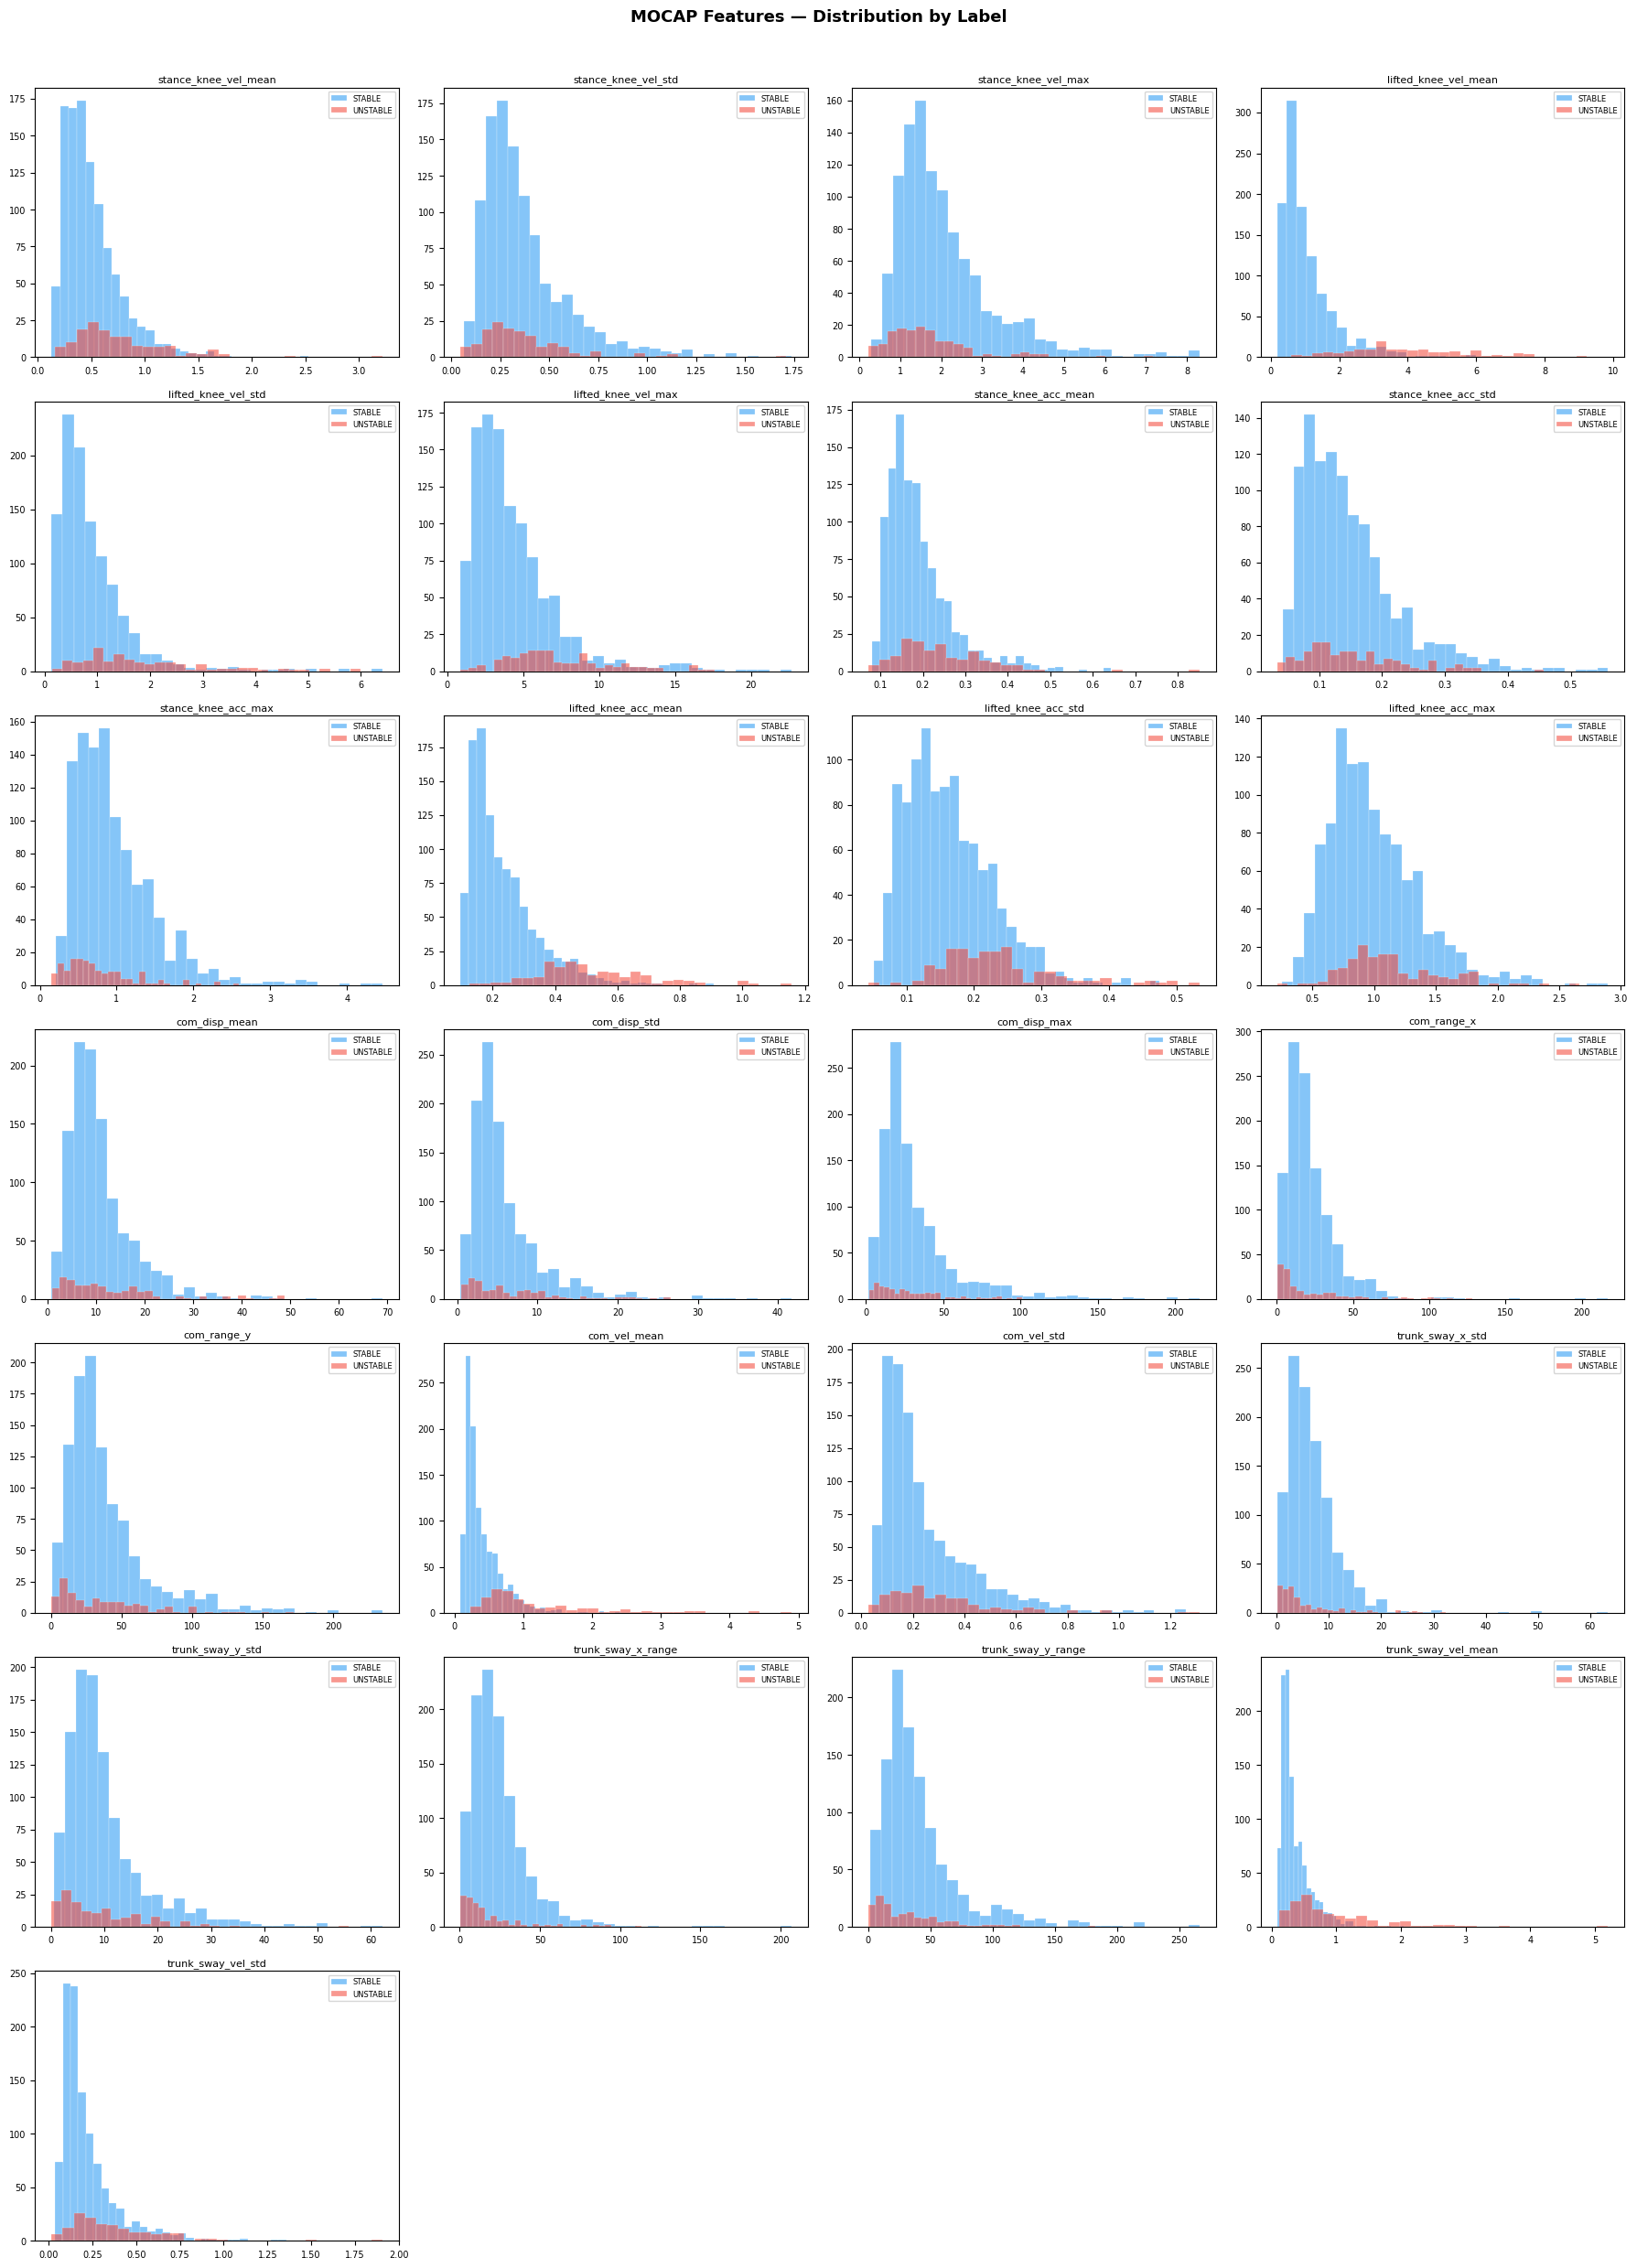

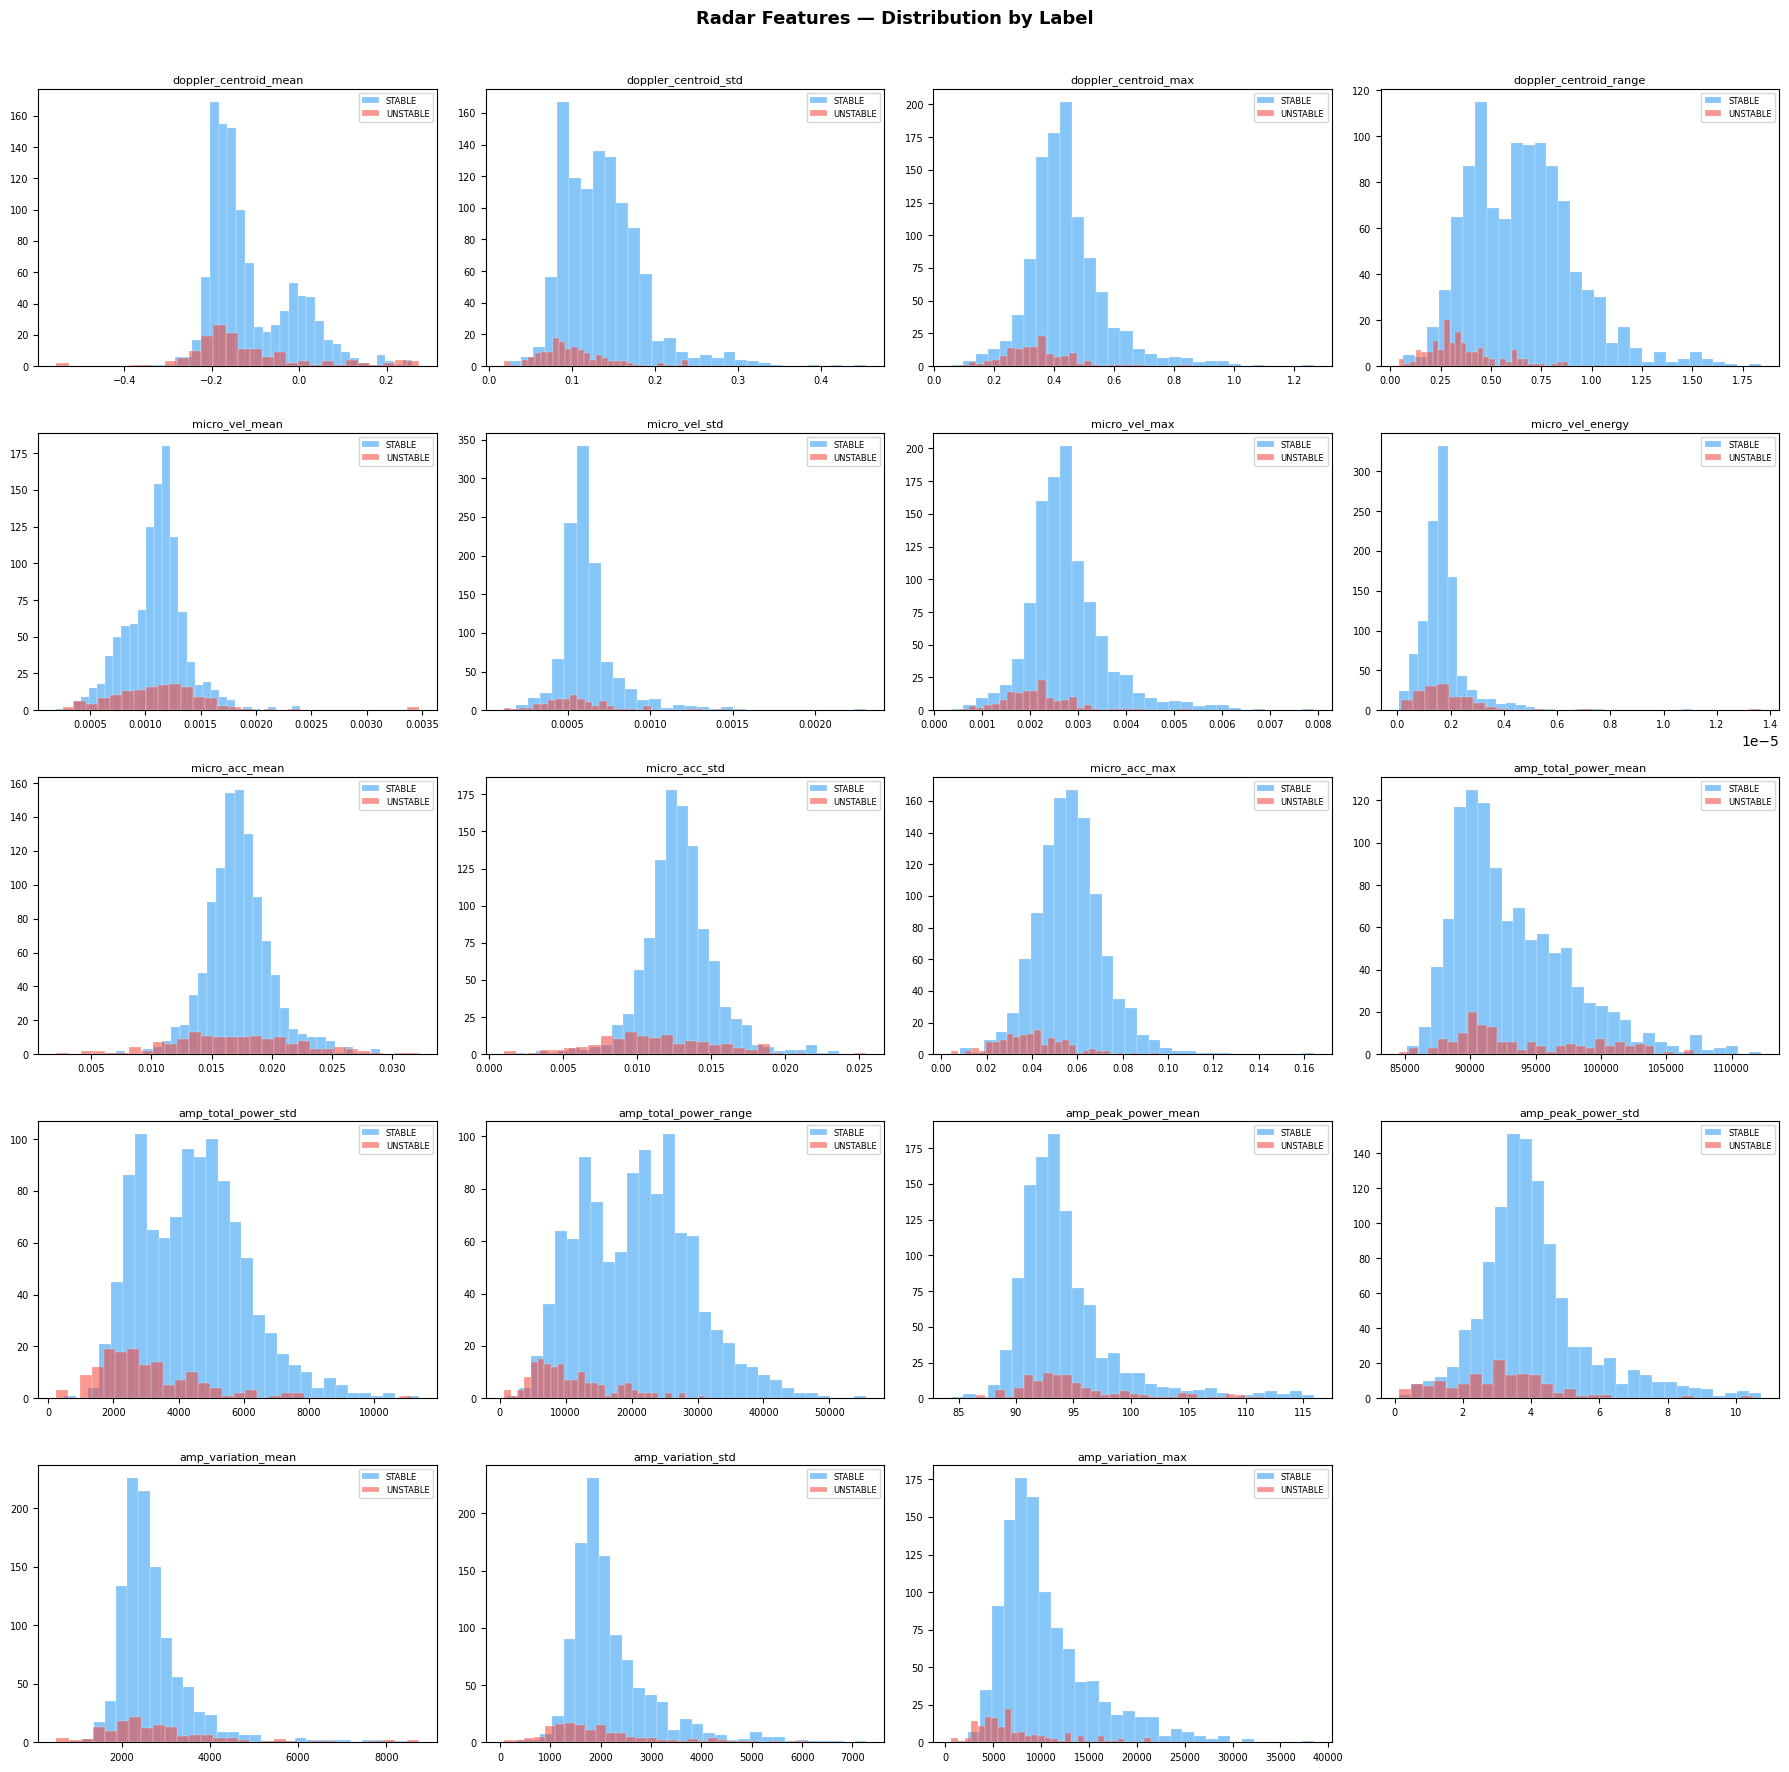

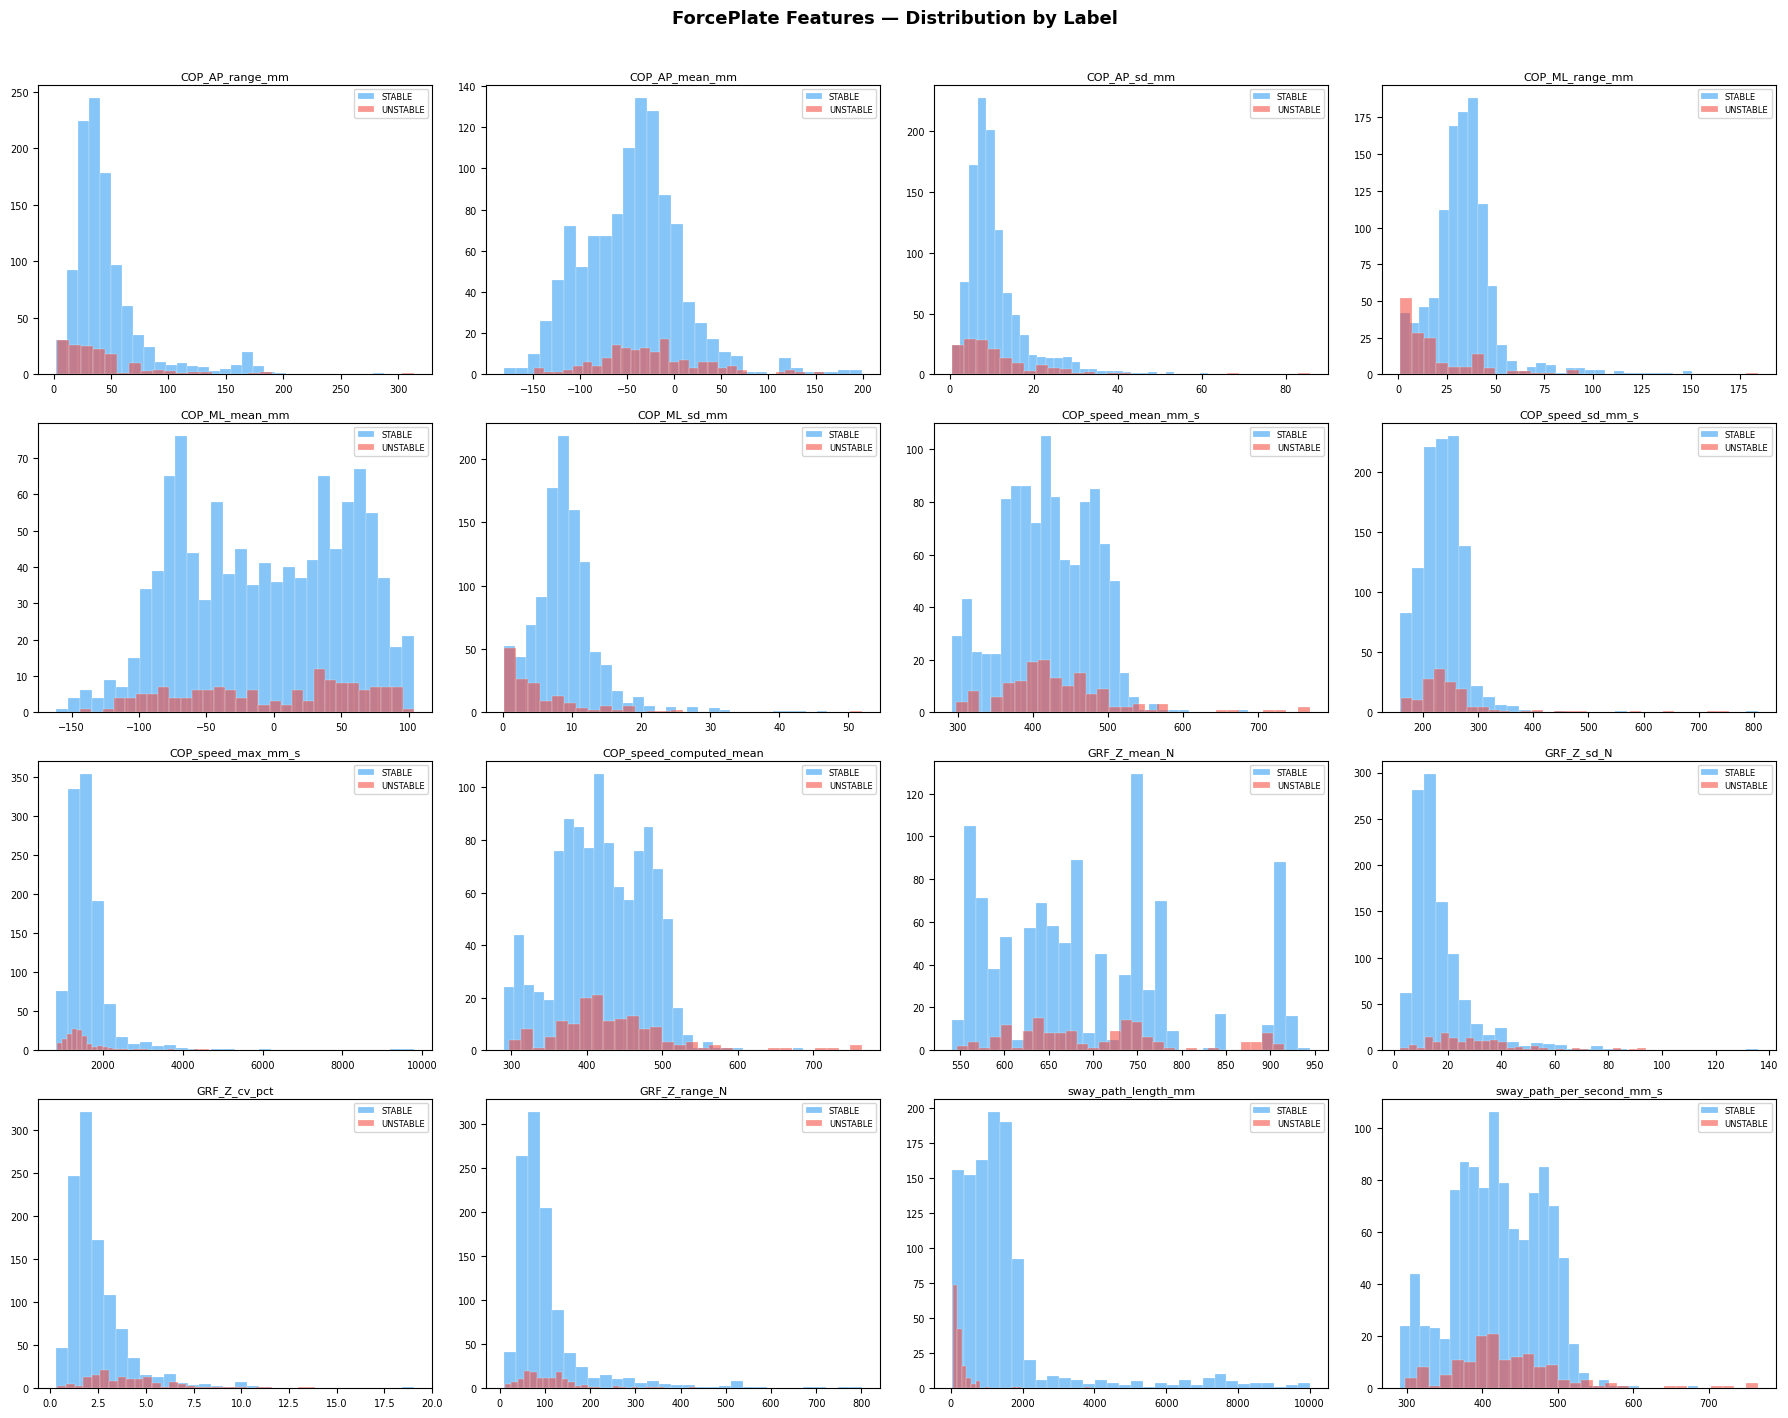

In [4]:
# Distribution plots per modality
def plot_distributions(cols, title, df, outcome_col='label'):
    n = len(cols)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5))
    axes = axes.flatten()
    palette = {'STABLE': '#2196F3', 'UNSTABLE': '#F44336'}
    for i, col in enumerate(cols):
        ax = axes[i]
        for lbl, grp in df.groupby(outcome_col):
            ax.hist(grp[col].dropna(), bins=30, alpha=0.55,
                    label=lbl, color=palette[lbl], edgecolor='white', linewidth=0.3)
        ax.set_title(col.split('_', 1)[1] if '_' in col else col, fontsize=8, pad=4)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'{title} — Distribution by Label', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'dist_{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_distributions(MOCAP_cols,   'MOCAP Features',      df)
plot_distributions(RADAR_cols,   'Radar Features',      df)
plot_distributions(FP_cols,      'ForcePlate Features', df)


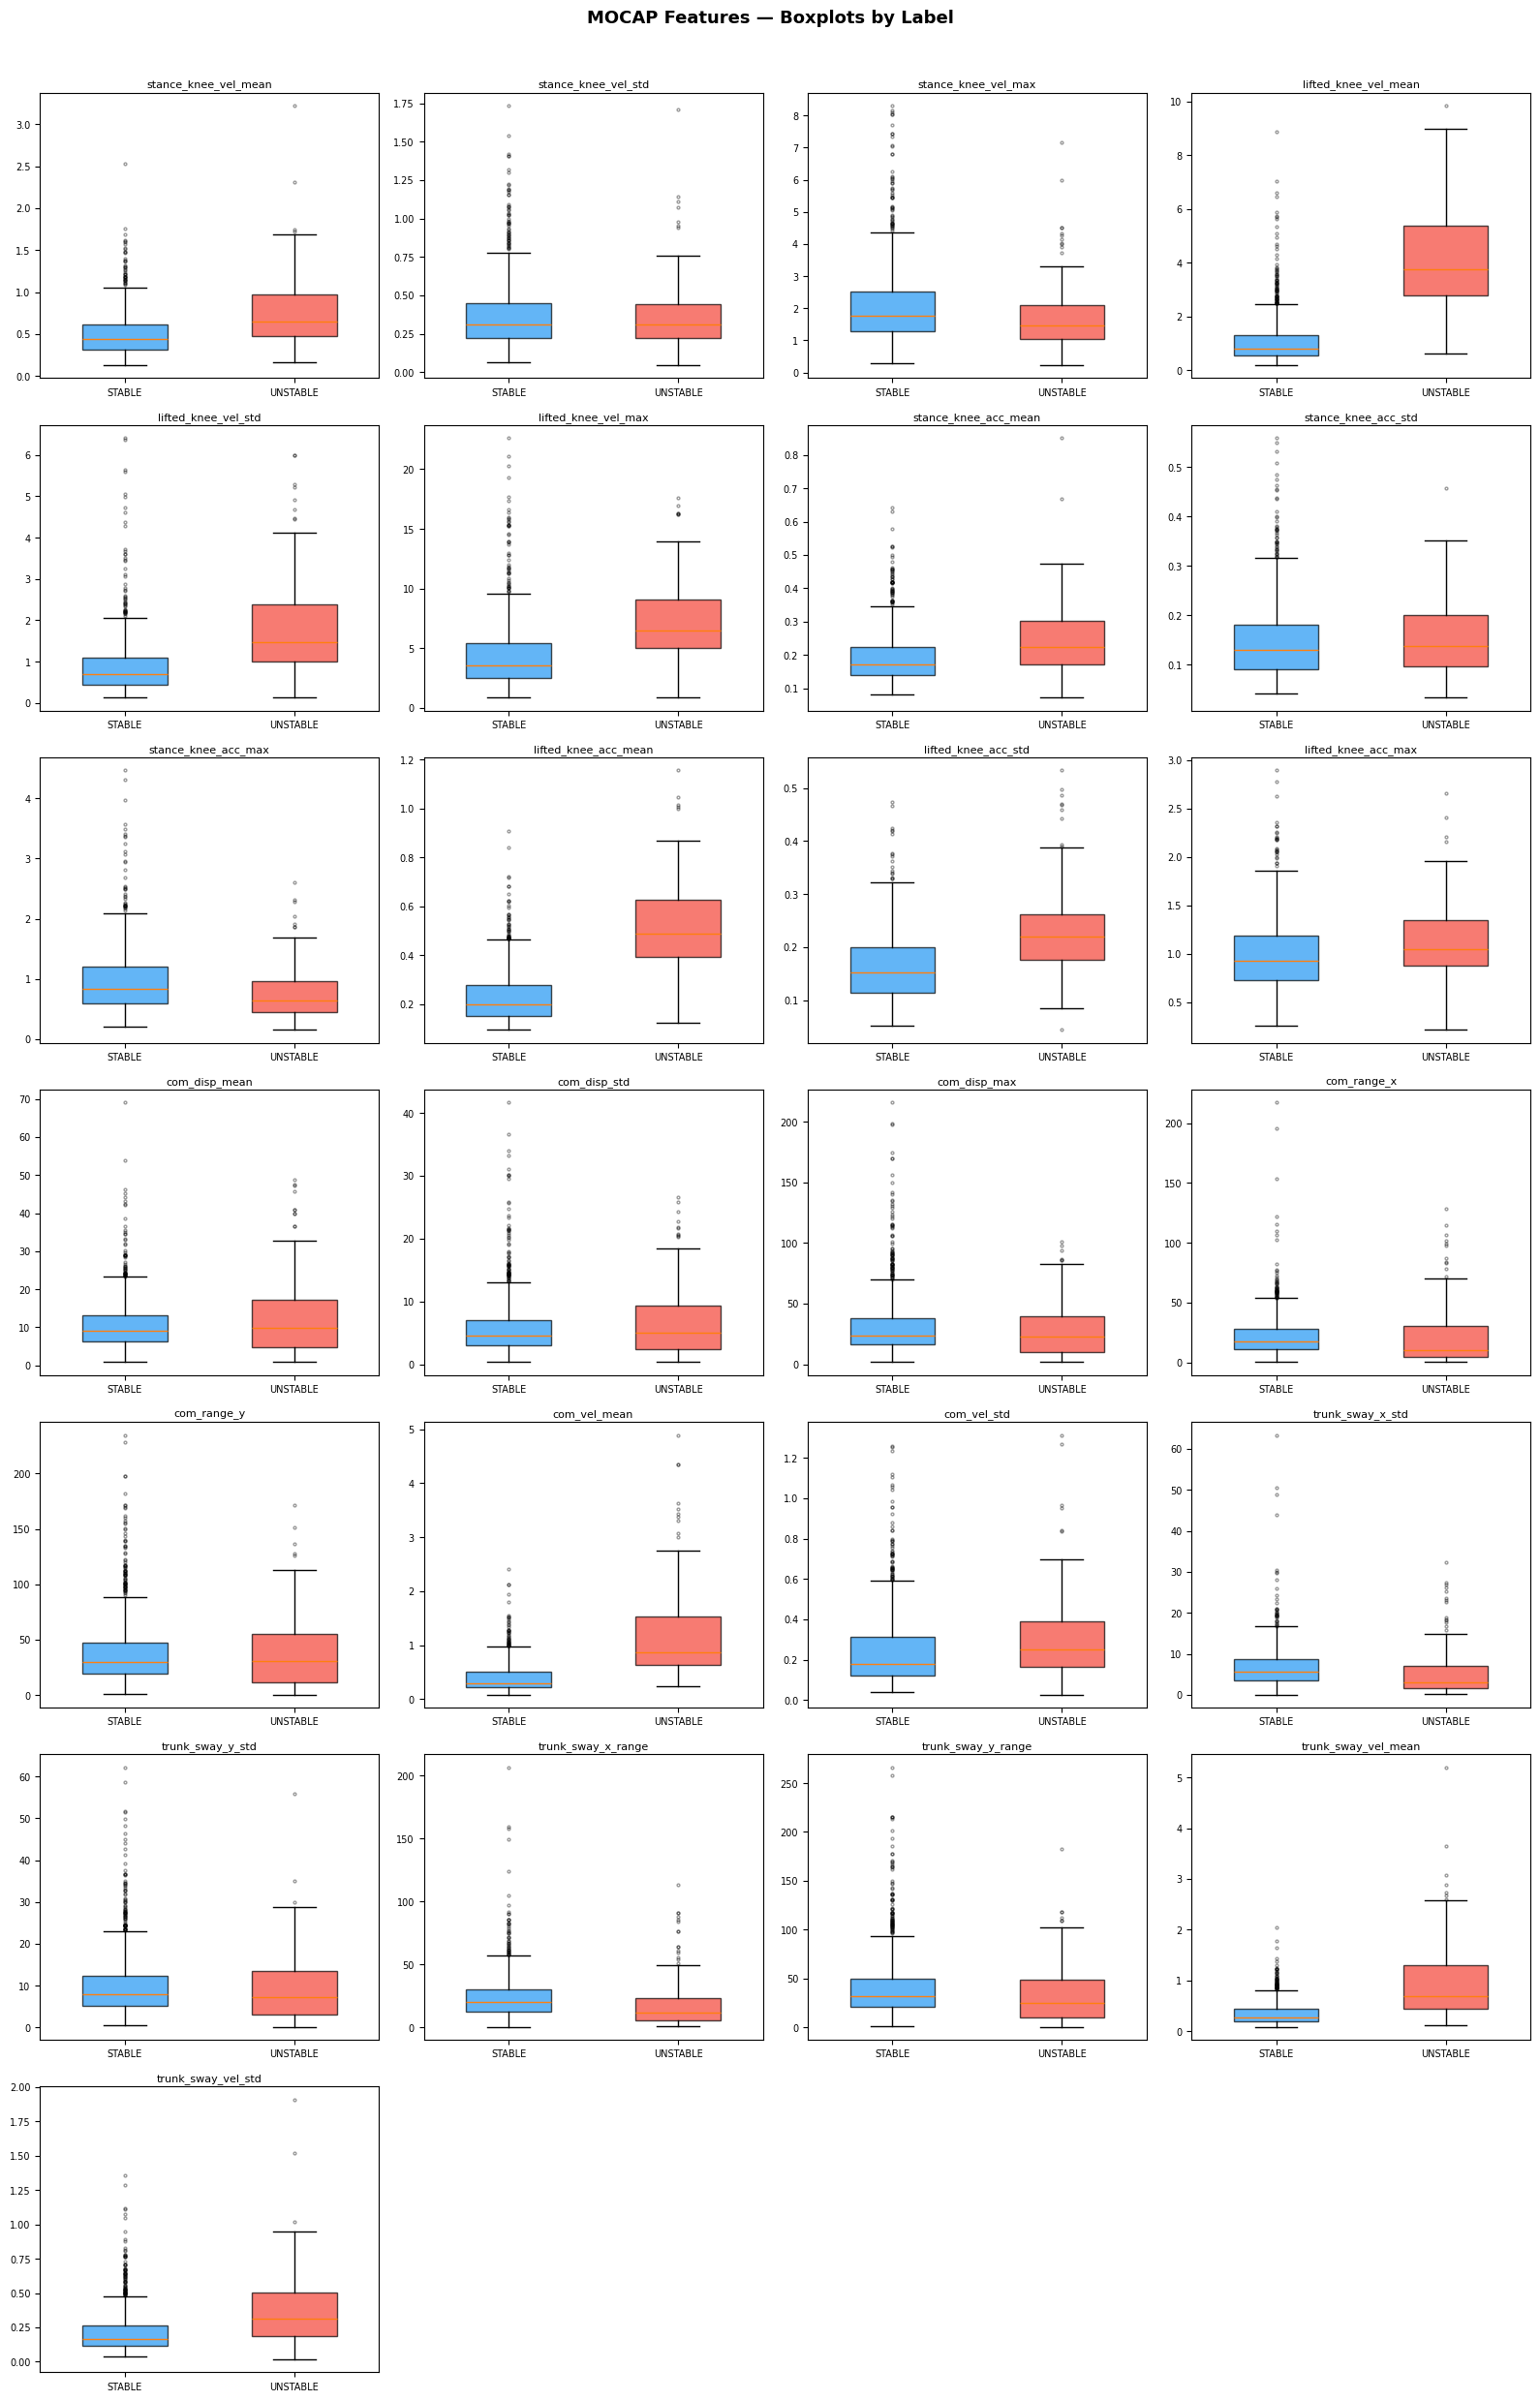

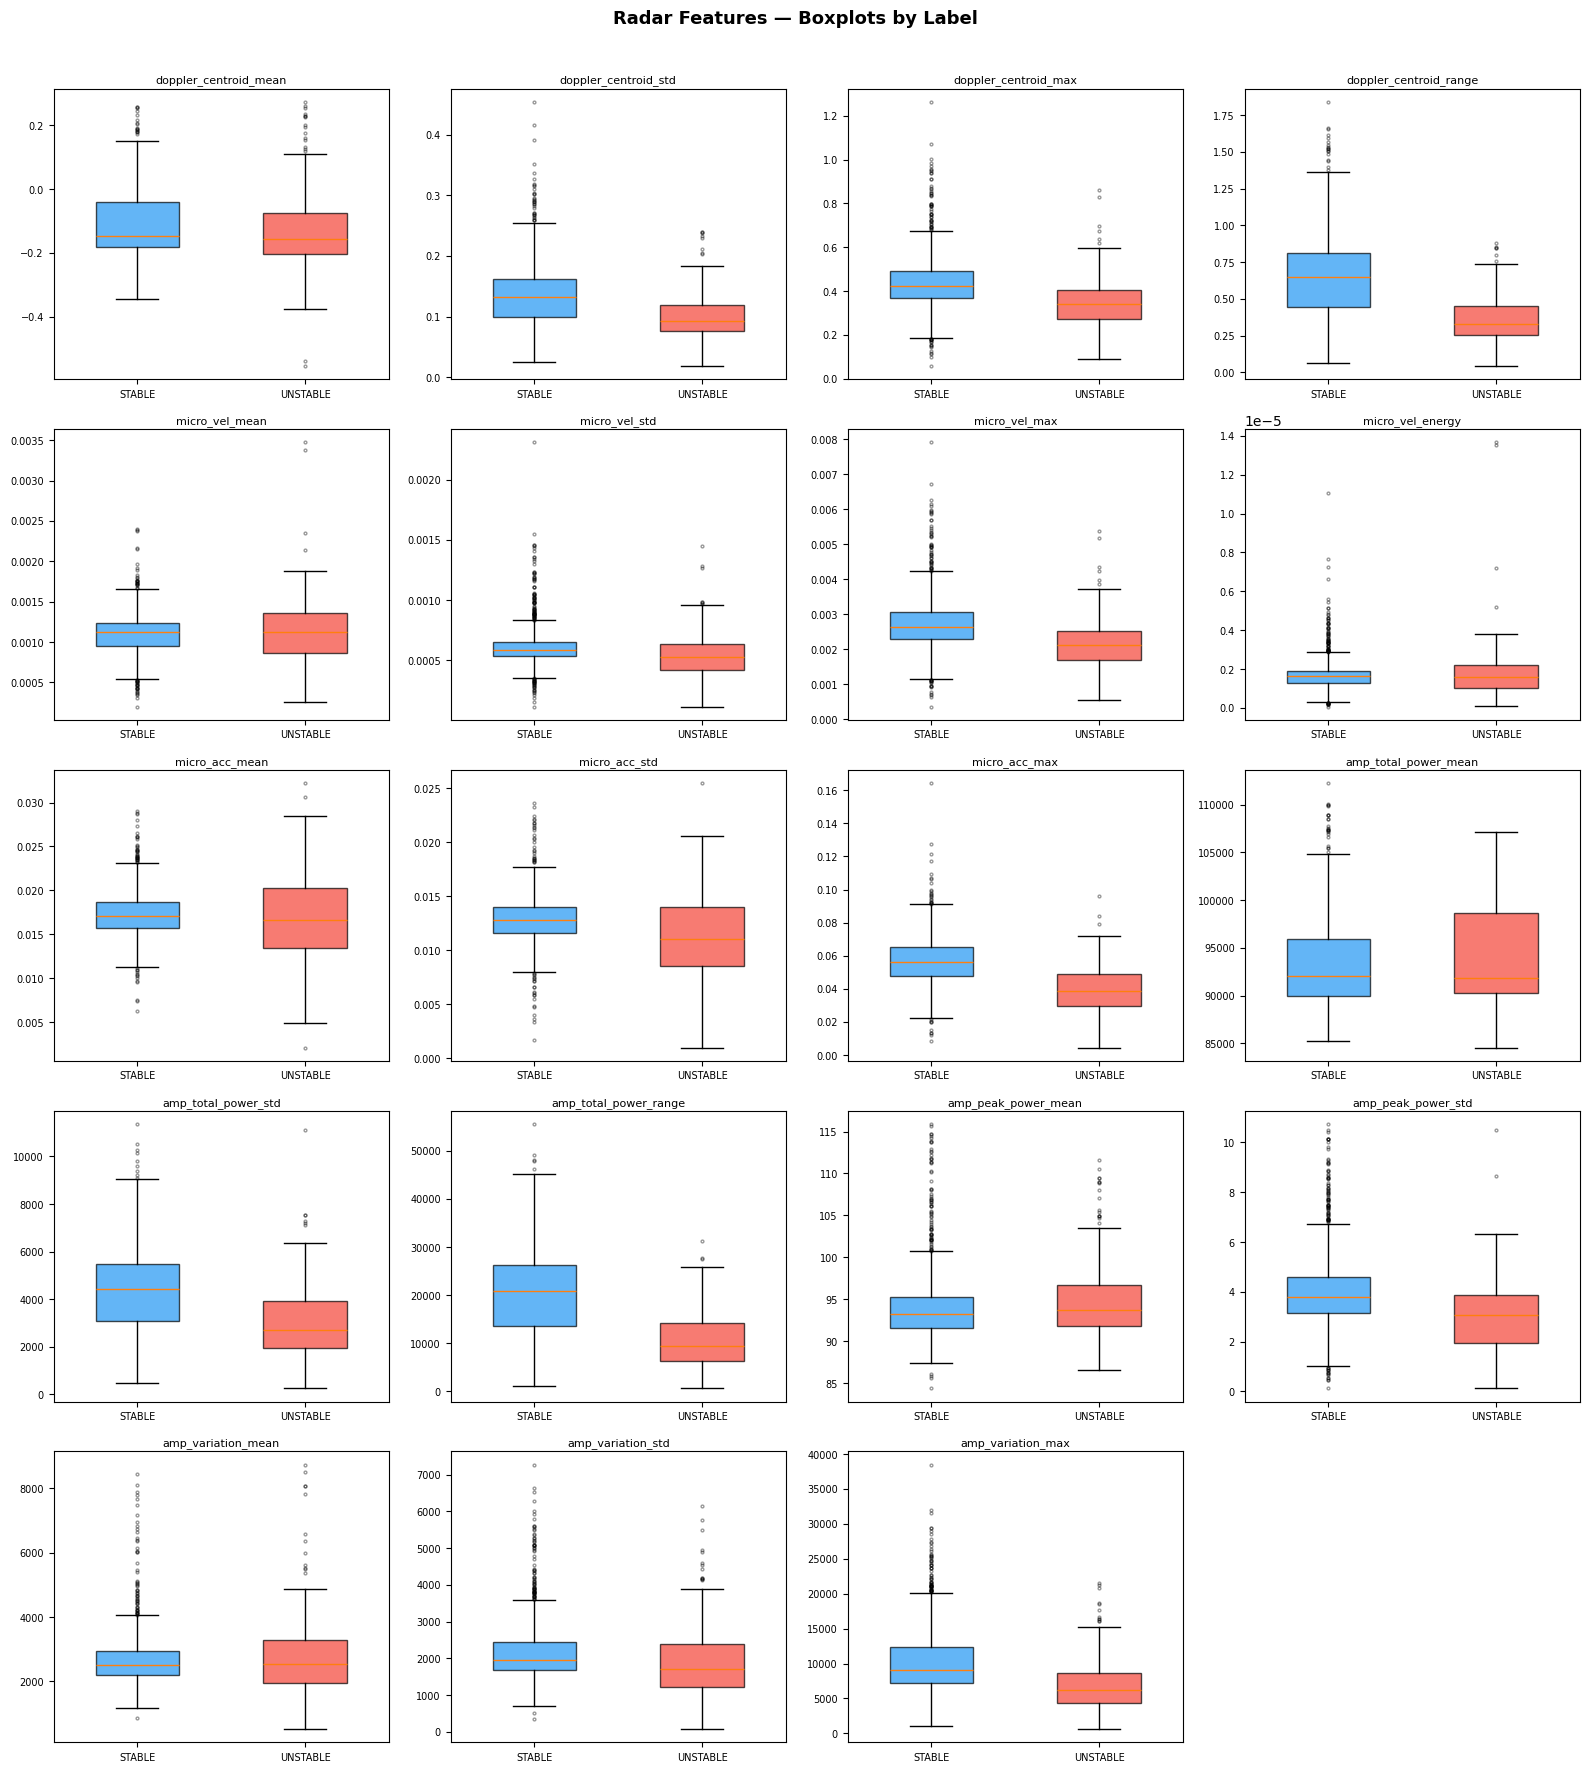

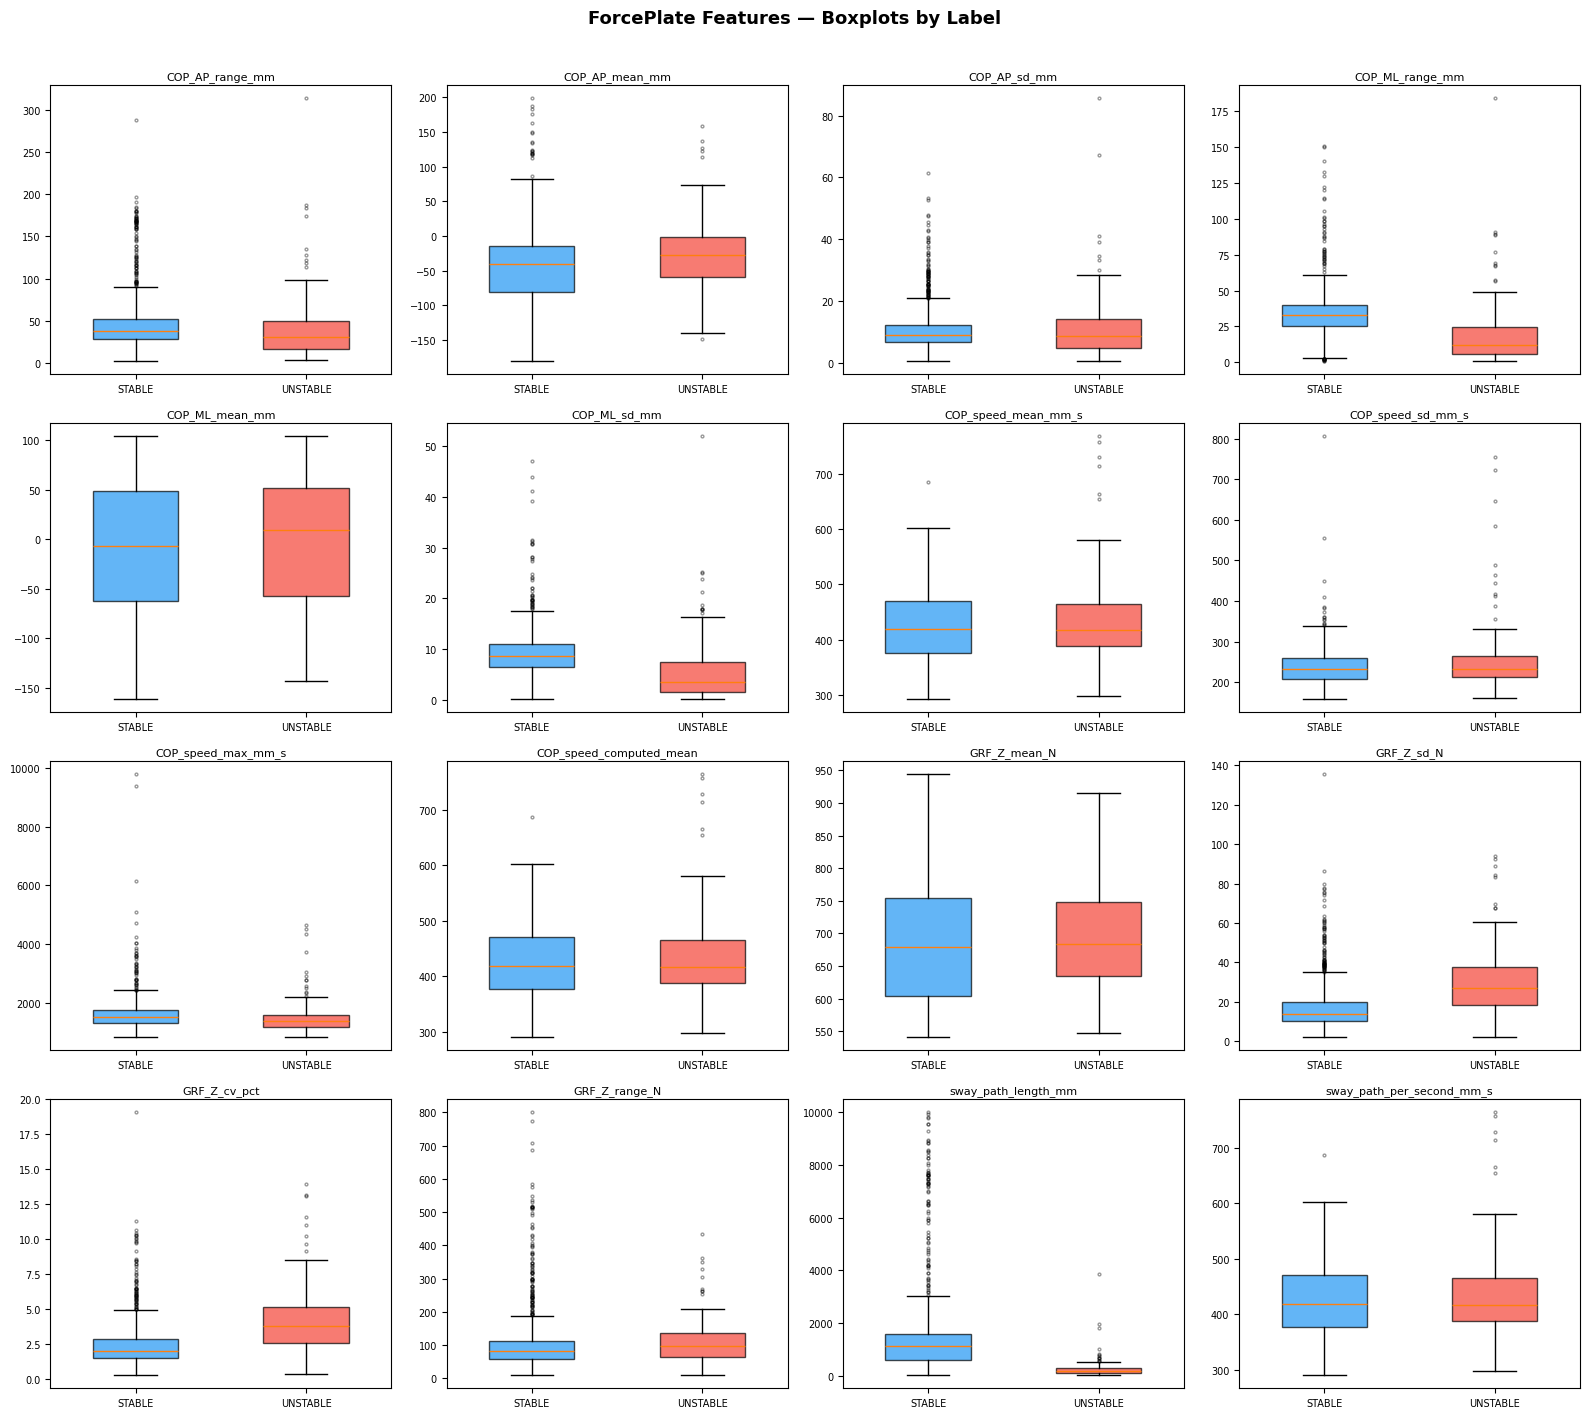

In [6]:
# Box plots per modality
def plot_boxplots(cols, title, df, outcome_col='label'):
    n = len(cols)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
    axes = axes.flatten()
    palette = {'STABLE': '#2196F3', 'UNSTABLE': '#F44336'}
    for i, col in enumerate(cols):
        ax = axes[i]
        data_to_plot = [df.loc[df[outcome_col] == lbl, col].dropna().values
                        for lbl in ['STABLE', 'UNSTABLE']]
        bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['STABLE', 'UNSTABLE'],
                        widths=0.5, showfliers=True,
                        flierprops=dict(marker='o', markersize=2, alpha=0.4))
        for patch, lbl in zip(bp['boxes'], ['STABLE', 'UNSTABLE']):
            patch.set_facecolor(palette[lbl]); patch.set_alpha(0.7)
        ax.set_title(col.split('_', 1)[1] if '_' in col else col, fontsize=8, pad=4)
        ax.tick_params(labelsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'{title} — Boxplots by Label', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'box_{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_boxplots(MOCAP_cols,   'MOCAP Features',      df)
plot_boxplots(RADAR_cols,   'Radar Features',      df)
plot_boxplots(FP_cols,      'ForcePlate Features', df)


## 3 · Statistical testing

In [5]:
# Shapiro-Wilk normality test (per group)
print("="*60)
print("SHAPIRO-WILK NORMALITY TEST (α = 0.05)")
print("="*60)

sw_results = []
for col in all_feature_cols:
    for lbl in ['STABLE', 'UNSTABLE']:
        data = df.loc[df['label'] == lbl, col].dropna()
        sample = data.sample(min(len(data), 5000), random_state=42) if len(data) > 5000 else data
        stat, p = stats.shapiro(sample)
        sw_results.append({'feature': col, 'source': col.split('_')[0],
                           'group': lbl, 'n': len(data),
                           'W': round(stat, 4), 'p_value': round(p, 6),
                           'normal': 'YES' if p > 0.05 else 'NO'})

sw_df = pd.DataFrame(sw_results)
both_normal = (sw_df.groupby('feature')
                    .apply(lambda x: (x['normal'] == 'YES').all())
                    .reset_index())
both_normal.columns = ['feature', 'both_groups_normal']
print(f"Features where BOTH groups normal → use t-test       : {both_normal['both_groups_normal'].sum()}")
print(f"Features where ANY group non-normal → use Mann-Whitney: {(~both_normal['both_groups_normal']).sum()}")
# Conclusion: most features are non-normal → Mann-Whitney throughout


SHAPIRO-WILK NORMALITY TEST (α = 0.05)
Features where BOTH groups normal → use t-test       : 0
Features where ANY group non-normal → use Mann-Whitney: 60


In [12]:
# Mann-Whitney U + rank-biserial effect size + FDR correction
results_mw = []
for col in all_feature_cols:
    stable   = df.loc[df['label'] == 'STABLE',   col].dropna()
    unstable = df.loc[df['label'] == 'UNSTABLE', col].dropna()
    u_stat, p_val = stats.mannwhitneyu(stable, unstable, alternative='two-sided')
    n1, n2 = len(stable), len(unstable)
    r_rb   = 1 - (2 * u_stat) / (n1 * n2)
    abs_r  = abs(r_rb)
    if   abs_r >= 0.50: magnitude = 'Large'
    elif abs_r >= 0.30: magnitude = 'Medium'
    elif abs_r >= 0.10: magnitude = 'Small'
    else:               magnitude = 'Negligible'
    results_mw.append({
        'feature': col, 'source': col.split('_')[0],
        'U_stat': round(u_stat, 2), 'p_raw': p_val,
        'r_rb': round(r_rb, 4), 'abs_r': round(abs_r, 4),
        'magnitude': magnitude,
        'med_STABLE':   round(stable.median(), 4),
        'med_UNSTABLE': round(unstable.median(), 4),
        'iqr_STABLE':   round(stable.quantile(0.75) - stable.quantile(0.25), 4),
        'iqr_UNSTABLE': round(unstable.quantile(0.75) - unstable.quantile(0.25), 4),
        'direction': 'UNSTABLE > STABLE' if r_rb < 0 else 'STABLE > UNSTABLE',
    })

mw_df = pd.DataFrame(results_mw)
rejected, p_fdr, _, _ = multipletests(mw_df['p_raw'], alpha=0.05, method='fdr_bh')
mw_df['p_fdr']       = p_fdr.round(6)
mw_df['significant'] = rejected
mw_df = mw_df.sort_values('abs_r', ascending=False).reset_index(drop=True)

print(f"Significant after FDR (p_fdr < 0.05): {mw_df['significant'].sum()} / {len(mw_df)}")
print("\nEffect size breakdown:")
print(mw_df['magnitude'].value_counts())
print("\nTop 15 features by effect size:")
print(mw_df[['feature','source','p_fdr','r_rb','magnitude','direction']].head(60).to_string(index=False))


Significant after FDR (p_fdr < 0.05): 41 / 60

Effect size breakdown:
magnitude
Negligible    18
Small         17
Large         15
Medium        10
Name: count, dtype: int64

Top 15 features by effect size:
                             feature     source    p_fdr    r_rb  magnitude         direction
          MOCAP_lifted_knee_vel_mean      MOCAP 0.000000  0.8947      Large STABLE > UNSTABLE
          MOCAP_lifted_knee_acc_mean      MOCAP 0.000000  0.8583      Large STABLE > UNSTABLE
      ForcePlate_sway_path_length_mm ForcePlate 0.000000 -0.8072      Large UNSTABLE > STABLE
                  MOCAP_com_vel_mean      MOCAP 0.000000  0.7847      Large STABLE > UNSTABLE
           MOCAP_trunk_sway_vel_mean      MOCAP 0.000000  0.6744      Large STABLE > UNSTABLE
        RADAR_doppler_centroid_range      RADAR 0.000000 -0.6680      Large UNSTABLE > STABLE
         RADAR_amp_total_power_range      RADAR 0.000000 -0.6642      Large UNSTABLE > STABLE
                 RADAR_micro_acc_max     

## 4 · Correlation analysis

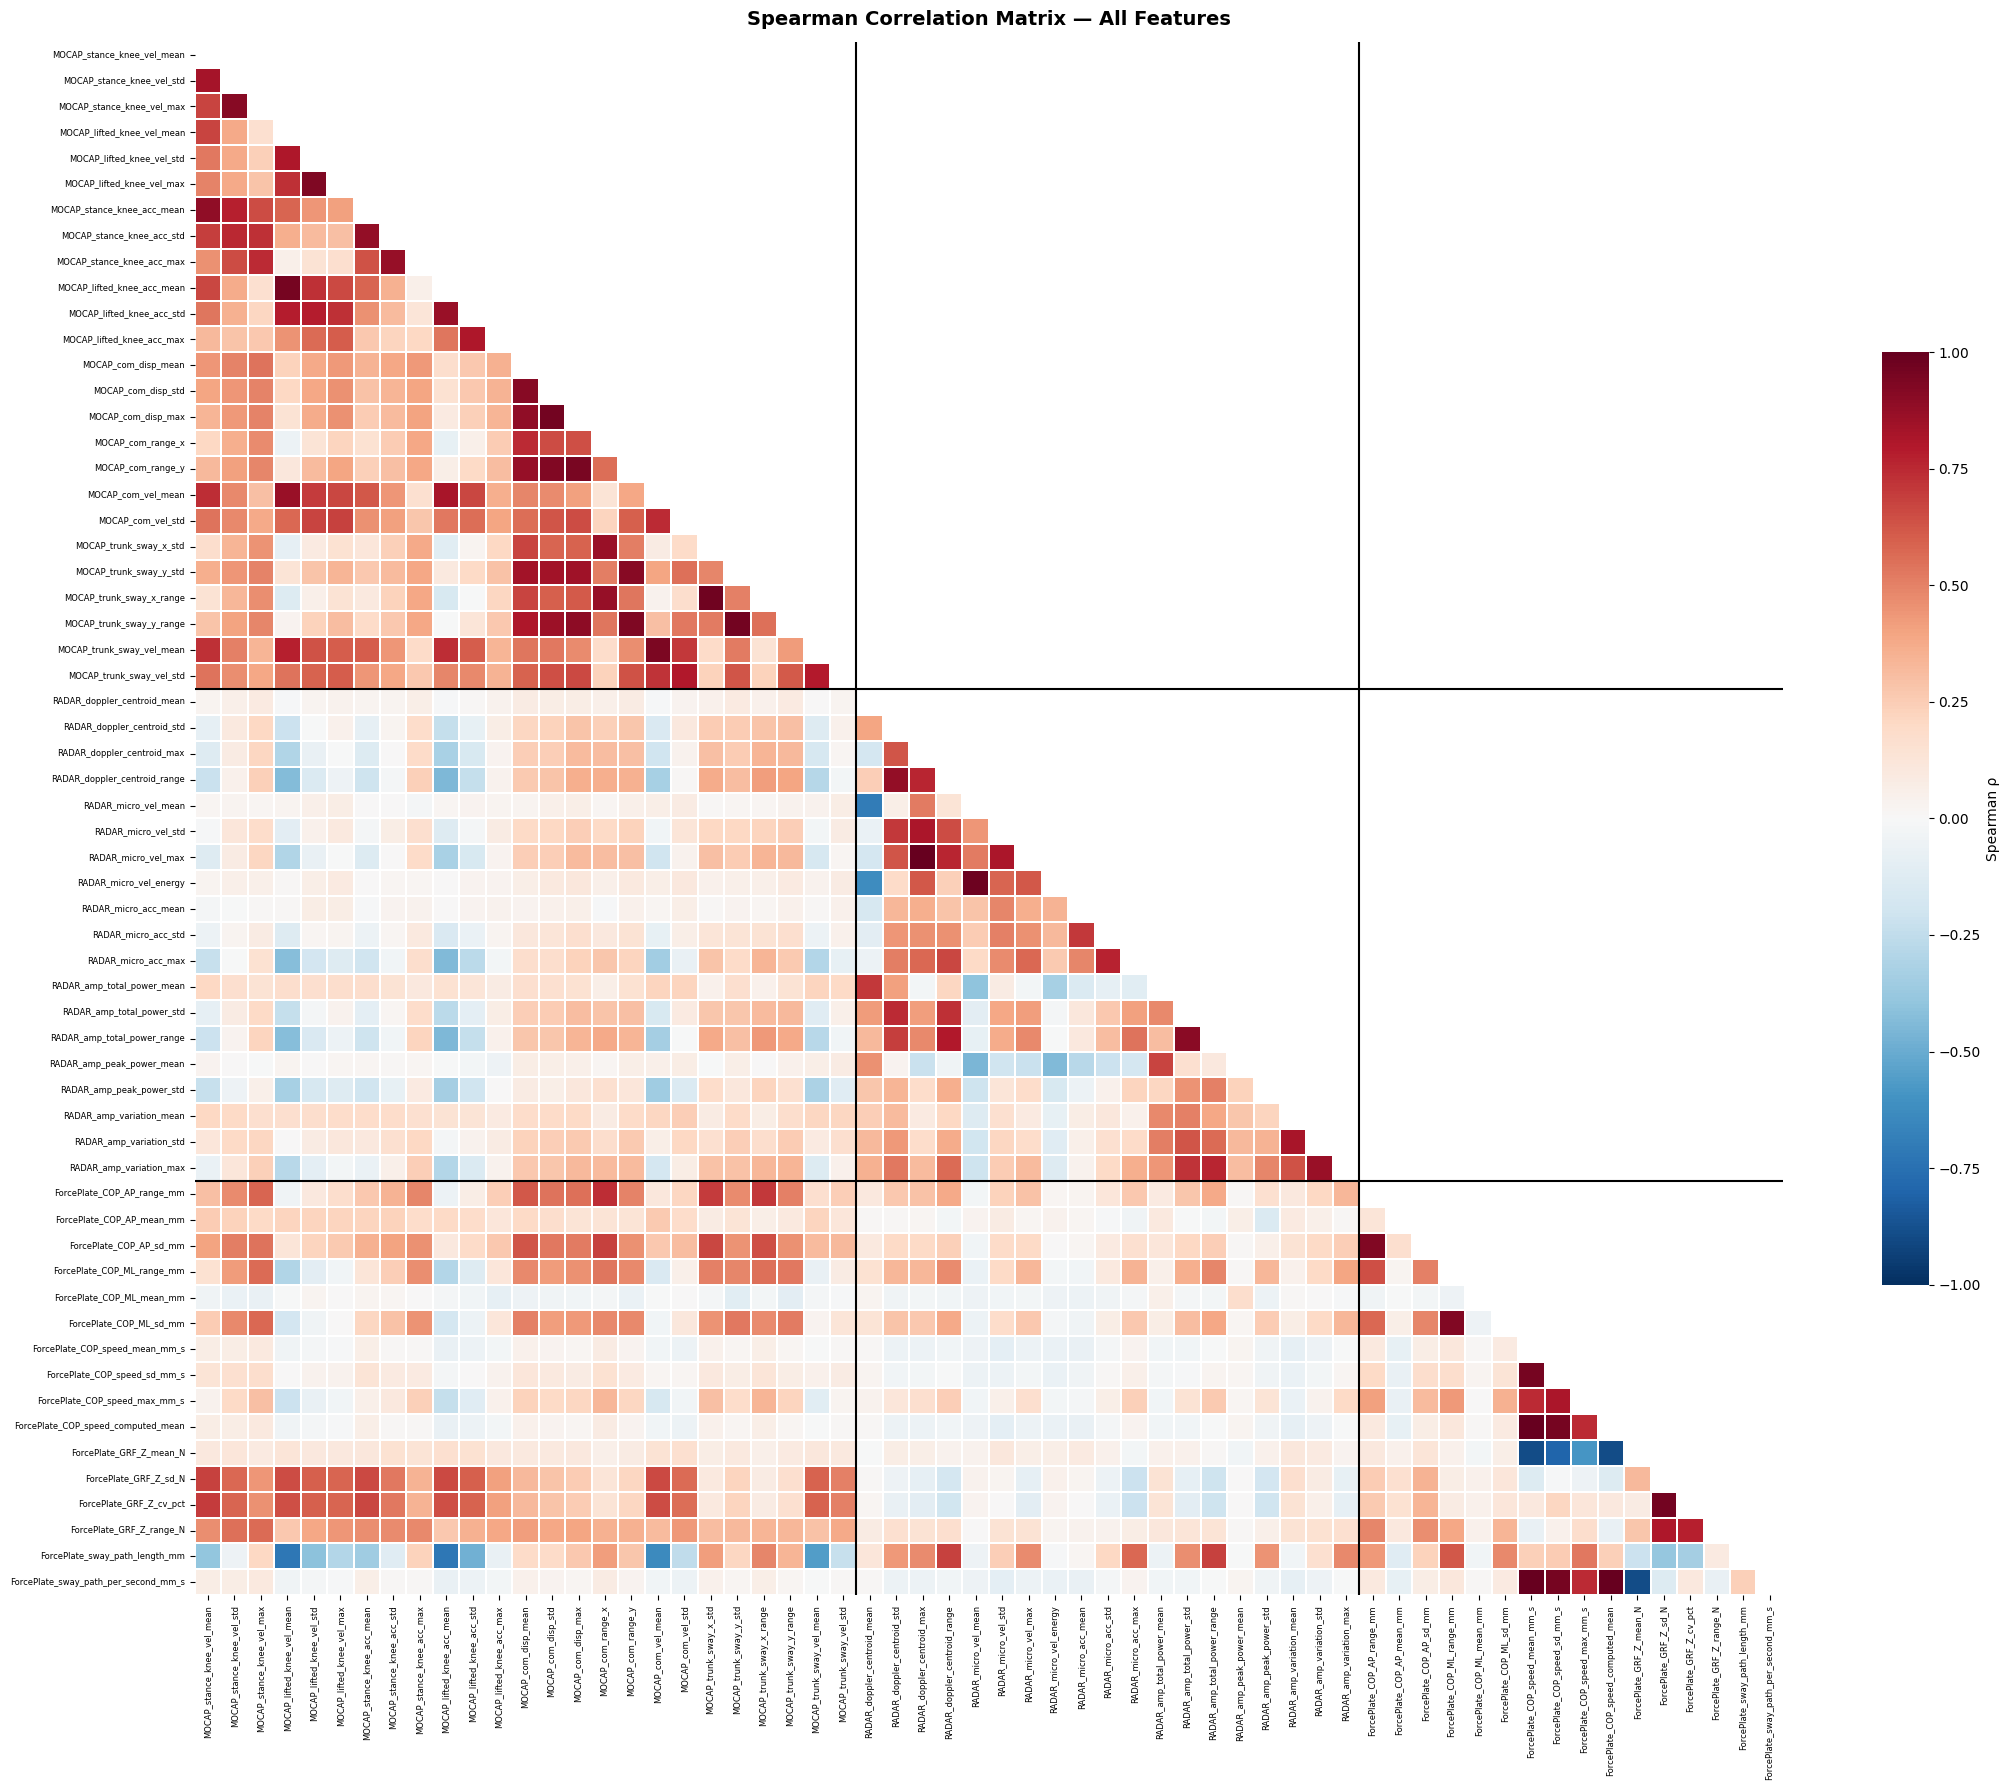

In [11]:
# Spearman correlation heatmap
corr_matrix = df[all_feature_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.2, linecolor='white', annot=False, ax=ax,
            cbar_kws={'label': 'Spearman ρ', 'shrink': 0.6})
n_mocap = len(MOCAP_cols); n_radar = len(RADAR_cols)
for b in [n_mocap, n_mocap + n_radar]:
    ax.axhline(b, color='black', linewidth=1.5)
    ax.axvline(b, color='black', linewidth=1.5)
ax.set_title('Spearman Correlation Matrix — All Features', fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig('corr_heatmap_full.png', dpi=130, bbox_inches='tight')
plt.show()


## 5 · ML — ALL features (LOSO)
All classifiers run on every modality using Leave-One-Subject-Out cross-validation.


In [7]:
# ─── Setup: labels, participants, modalities ───────────────────────────────
y            = (df['label'] == 'UNSTABLE').astype(int).values   # 1=UNSTABLE, 0=STABLE
participants = df['participant_id'].values

modalities = {
    'MOCAP':       MOCAP_cols,
    'Radar':       RADAR_cols,
    'ForcePlate':  FP_cols,
    'All':         all_feature_cols,
}

print(f"Class balance — STABLE: {(y==0).sum()}  UNSTABLE: {(y==1).sum()}")
print(f"Participants: {len(np.unique(participants))}")
print(f"Features — MOCAP:{len(MOCAP_cols)}  Radar:{len(RADAR_cols)}  FP:{len(FP_cols)}")


Class balance — STABLE: 1073  UNSTABLE: 151
Participants: 32
Features — MOCAP:25  Radar:19  FP:16


In [8]:
# ─── Classifiers ────────────────────────────────────────────────────────────
classifiers = {
    'LogReg': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=0.1),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=6, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        eval_metric='logloss', random_state=42,
        use_label_encoder=False, verbosity=0),
}


In [9]:
# ─── LOSO evaluation function ─────────────────────────────────────────────
def loso_evaluate(X, y, participants, clf, clf_name, modality_name,
                  scale=True, use_pca=False, n_components=None):
    unique_pids = np.unique(participants)
    fold_results = []
    all_y_true, all_y_pred, all_y_prob = [], [], []

    for pid in unique_pids:
        test_idx  = np.where(participants == pid)[0]
        train_idx = np.where(participants != pid)[0]
        X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
        y_tr, y_te = y[train_idx], y[test_idx]

        if len(np.unique(y_te)) < 2:
            continue

        # Impute with training median
        tr_med = np.nanmedian(X_tr, axis=0)
        for j in range(X_tr.shape[1]):
            X_tr[np.isnan(X_tr[:, j]), j] = tr_med[j]
            X_te[np.isnan(X_te[:, j]), j] = tr_med[j]

        if scale:
            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        if use_pca and n_components:
            pca_  = PCA(n_components=n_components)
            X_tr  = pca_.fit_transform(X_tr)
            X_te  = pca_.transform(X_te)

        # Fresh clone to avoid state leakage between folds
        import copy
        clf_fold = copy.deepcopy(clf)
        clf_fold.fit(X_tr, y_tr)
        y_pred = clf_fold.predict(X_te)
        y_prob = clf_fold.predict_proba(X_te)[:, 1] if hasattr(clf_fold, 'predict_proba') else y_pred

        fold_results.append({
            'participant': pid,
            'auc':  roc_auc_score(y_te, y_prob),
            'f1':   f1_score(y_te, y_pred, zero_division=0),
            'bac':  balanced_accuracy_score(y_te, y_pred),
            'n_test': len(y_te), 'n_unstable': y_te.sum(),
        })
        all_y_true.extend(y_te); all_y_pred.extend(y_pred); all_y_prob.extend(y_prob)

    fd = pd.DataFrame(fold_results)
    yt = np.array(all_y_true); yp = np.array(all_y_pred); yprob = np.array(all_y_prob)

    summary = {
        'modality':   modality_name, 'classifier': clf_name,
        'AUC_mean':   fd['auc'].mean(), 'AUC_std':  fd['auc'].std(),
        'F1_mean':    fd['f1'].mean(),  'F1_std':   fd['f1'].std(),
        'BAC_mean':   fd['bac'].mean(), 'BAC_std':  fd['bac'].std(),
        'AUC_pooled': roc_auc_score(yt, yprob),
        'F1_pooled':  f1_score(yt, yp, zero_division=0),
        'n_folds':    len(fd),
    }
    return summary, fd, yt, yp, yprob

print("LOSO function defined.")


LOSO function defined.


In [15]:
# ─── Run LOSO — ALL features (baseline) ─────────────────────────────────────
print("="*65)
print("LOSO — ALL FEATURES (baseline)")
print("="*65)

results_all_feat = []
roc_data_all     = {}
fold_details_all = {}

for mod_name, feat_cols in modalities.items():
    X_mod = df[feat_cols].values.astype(float)
    for clf_name, clf in classifiers.items():
        print(f"  {mod_name:12s} | {clf_name:15s}", end=" ... ")
        summary, fd, yt, yp, yprob = loso_evaluate(
            X_mod.copy(), y.copy(), participants.copy(),
            clf=clf, clf_name=clf_name, modality_name=mod_name,
            scale=True, use_pca=False,
        )
        summary['approach'] = 'All features'
        results_all_feat.append(summary)
        fold_details_all[f"{mod_name}_{clf_name}"] = fd
        if clf_name == 'XGBoost':
            fpr, tpr, _ = roc_curve(yt, yprob)
            roc_data_all[mod_name] = (fpr, tpr, summary['AUC_pooled'])
        print(f"AUC={summary['AUC_mean']:.3f}±{summary['AUC_std']:.3f}  "
              f"F1={summary['F1_mean']:.3f}  BAC={summary['BAC_mean']:.3f}")

df_res_all = pd.DataFrame(results_all_feat)
print("\nAll-features results:")
print(df_res_all[['modality','classifier','AUC_mean','AUC_std','F1_mean','BAC_mean']].to_string(index=False))


LOSO — ALL FEATURES (baseline)
AUC=0.956±0.076  F1=0.751  BAC=0.902 
AUC=0.956±0.067  F1=0.733  BAC=0.874 
AUC=0.966±0.051  F1=0.795  BAC=0.888 
AUC=0.885±0.127  F1=0.504  BAC=0.800 
AUC=0.877±0.102  F1=0.506  BAC=0.732 
AUC=0.879±0.105  F1=0.487  BAC=0.735 
AUC=0.916±0.099  F1=0.596  BAC=0.835 
AUC=0.906±0.096  F1=0.508  BAC=0.736 
AUC=0.913±0.100  F1=0.557  BAC=0.780 
AUC=0.956±0.076  F1=0.722  BAC=0.895 
AUC=0.945±0.078  F1=0.746  BAC=0.859 
AUC=0.961±0.050  F1=0.745  BAC=0.868 

All-features results:
  modality   classifier  AUC_mean  AUC_std  F1_mean  BAC_mean
     MOCAP       LogReg  0.956444 0.075760 0.751227  0.901727
     MOCAP RandomForest  0.955909 0.066909 0.732981  0.873787
     MOCAP      XGBoost  0.965731 0.050666 0.795418  0.887576
     Radar       LogReg  0.885295 0.126899 0.504015  0.799950
     Radar RandomForest  0.877389 0.101551 0.505694  0.731924
     Radar      XGBoost  0.878938 0.104975 0.487175  0.734688
ForcePlate       LogReg  0.916247 0.098662 0.596230  0.8

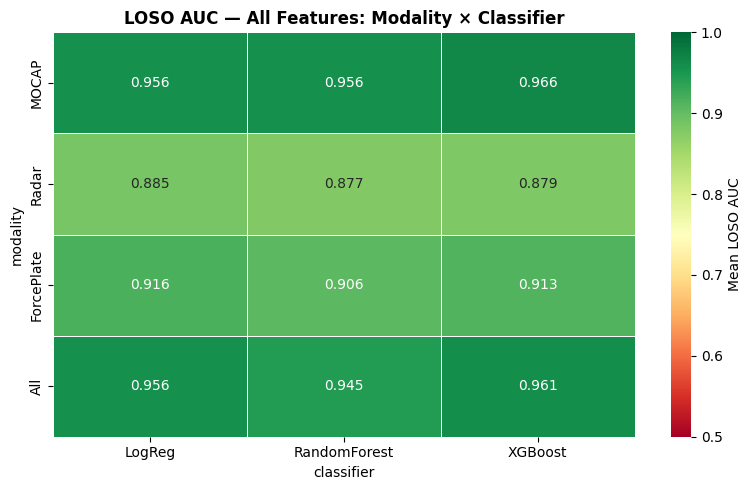

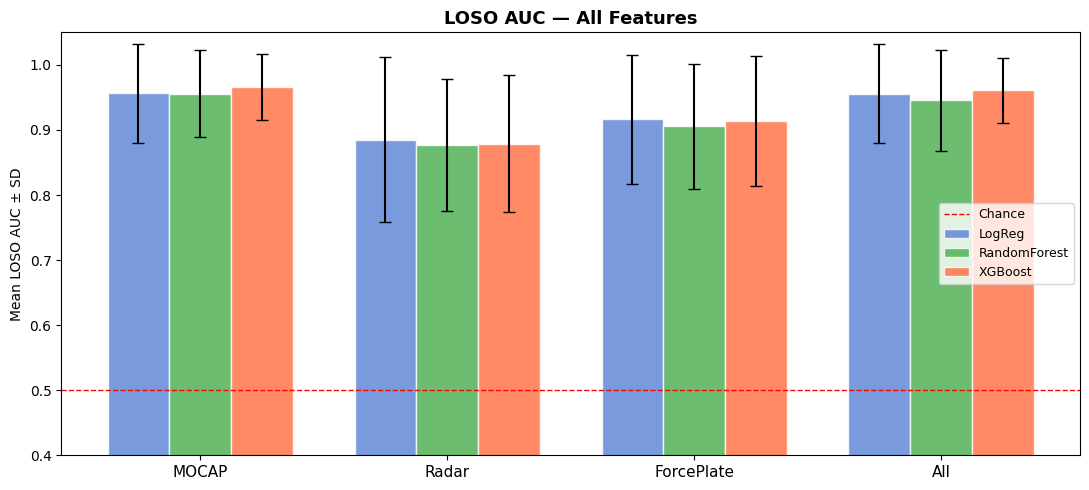

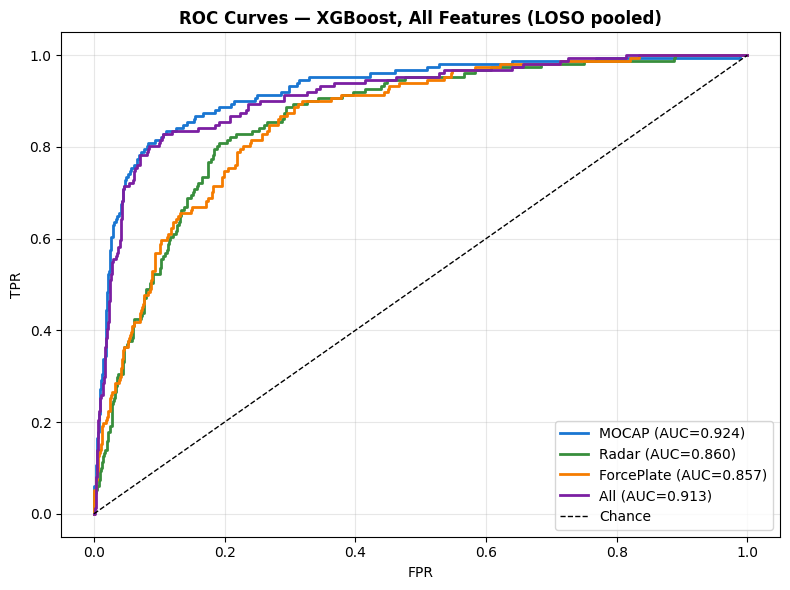

In [16]:
# ─── Plots: All-features baseline ───────────────────────────────────────────
mod_order = ['MOCAP','Radar','ForcePlate','All']
clf_order = ['LogReg','RandomForest','XGBoost']

# Heatmap
pivot = df_res_all.pivot(index='modality', columns='classifier', values='AUC_mean').reindex(mod_order)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Mean LOSO AUC'}, ax=ax)
ax.set_title('LOSO AUC — All Features: Modality × Classifier', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('loso_auc_heatmap_all.png', dpi=120, bbox_inches='tight'); plt.show()

# Bar chart with error bars
x = np.arange(len(mod_order)); width = 0.25
colors_clf = ['#5C85D6','#4CAF50','#FF7043']
fig, ax = plt.subplots(figsize=(11, 5))
for i, (cname, color) in enumerate(zip(clf_order, colors_clf)):
    sub = df_res_all[df_res_all['classifier']==cname].set_index('modality').reindex(mod_order)
    ax.bar(x + i*width, sub['AUC_mean'], width, yerr=sub['AUC_std'], capsize=4,
           color=color, alpha=0.82, label=cname, edgecolor='white')
ax.set_xticks(x + width); ax.set_xticklabels(mod_order, fontsize=11)
ax.set_ylabel('Mean LOSO AUC ± SD'); ax.set_ylim(0.4, 1.05)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Chance')
ax.set_title('LOSO AUC — All Features', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('loso_auc_bars_all.png', dpi=120, bbox_inches='tight'); plt.show()

# ROC curves (XGBoost)
mod_colors_roc = {'MOCAP':'#1976D2','Radar':'#388E3C','ForcePlate':'#F57C00','All':'#7B1FA2'}
fig, ax = plt.subplots(figsize=(8, 6))
for mod, (fpr, tpr, auc_val) in roc_data_all.items():
    ax.plot(fpr, tpr, linewidth=2, color=mod_colors_roc[mod], label=f'{mod} (AUC={auc_val:.3f})')
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Chance')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.grid(alpha=0.3)
ax.set_title('ROC Curves — XGBoost, All Features (LOSO pooled)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig('roc_all_features.png', dpi=120, bbox_inches='tight'); plt.show()


## 6 · PCA feature reduction + ML (LOSO)
PCA is fit **inside each LOSO fold** (on training data only, then applied to test) to prevent data leakage.
Components are chosen to retain 95% of variance per modality.


PCA — Variance Explained per Modality
  MOCAP       : 25 features → n90=6  n95=9
  Radar       : 19 features → n90=7  n95=9
  ForcePlate  : 16 features → n90=6  n95=7
  All         : 60 features → n90=17  n95=23


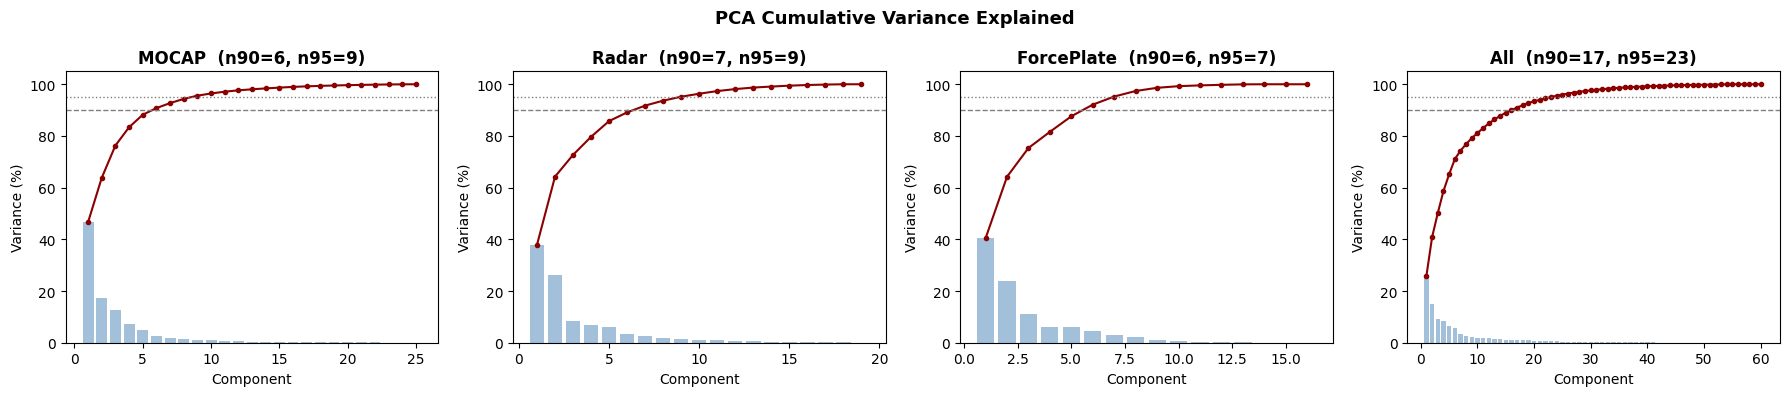

In [17]:
# ─── PCA variance exploration ────────────────────────────────────────────────
print("="*60)
print("PCA — Variance Explained per Modality")
print("="*60)

pca_info = {}
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, cols) in zip(axes, [
        ('MOCAP', MOCAP_cols), ('Radar', RADAR_cols),
        ('ForcePlate', FP_cols), ('All', all_feature_cols)]):
    X_sub = df[cols].fillna(df[cols].median())
    X_sc  = StandardScaler().fit_transform(X_sub)
    pca_  = PCA().fit(X_sc)
    cumvar = np.cumsum(pca_.explained_variance_ratio_) * 100
    n90 = int(np.argmax(cumvar >= 90) + 1)
    n95 = int(np.argmax(cumvar >= 95) + 1)
    ax.bar(range(1, len(cumvar)+1), pca_.explained_variance_ratio_*100, alpha=0.5, color='steelblue')
    ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='darkred', markersize=3, linewidth=1.5)
    ax.axhline(90, color='grey', linestyle='--', linewidth=1, label='90%')
    ax.axhline(95, color='grey', linestyle=':', linewidth=1, label='95%')
    ax.set_title(f'{name}  (n90={n90}, n95={n95})', fontweight='bold')
    ax.set_xlabel('Component'); ax.set_ylabel('Variance (%)'); ax.set_ylim(0, 105)
    pca_info[name] = {'n90': n90, 'n95': n95, 'cols': cols}
    print(f"  {name:12s}: {len(cols)} features → n90={n90}  n95={n95}")

plt.suptitle('PCA Cumulative Variance Explained', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('pca_variance.png', dpi=120, bbox_inches='tight'); plt.show()


In [18]:
# ─── Run LOSO — PCA (95% variance) ──────────────────────────────────────────
print("="*65)
print("LOSO — PCA-REDUCED FEATURES (95% variance)")
print("="*65)

results_pca = []
roc_data_pca = {}

for mod_name, feat_cols in modalities.items():
    X_mod  = df[feat_cols].values.astype(float)
    n_comp = pca_info[mod_name]['n95']
    for clf_name, clf in classifiers.items():
        print(f"  {mod_name:12s} ({n_comp} PCs) | {clf_name:15s}", end=" ... ")
        summary, fd, yt, yp, yprob = loso_evaluate(
            X_mod.copy(), y.copy(), participants.copy(),
            clf=clf, clf_name=clf_name,
            modality_name=f'{mod_name}_PCA{n_comp}',
            scale=True, use_pca=True, n_components=n_comp,
        )
        summary['approach'] = 'PCA'
        summary['modality_base'] = mod_name
        summary['n_components']  = n_comp
        results_pca.append(summary)
        if clf_name == 'XGBoost':
            fpr, tpr, _ = roc_curve(yt, yprob)
            roc_data_pca[mod_name] = (fpr, tpr, summary['AUC_pooled'])
        print(f"AUC={summary['AUC_mean']:.3f}±{summary['AUC_std']:.3f}  "
              f"F1={summary['F1_mean']:.3f}  BAC={summary['BAC_mean']:.3f}")

df_res_pca = pd.DataFrame(results_pca)
print("\nPCA results:")
print(df_res_pca[['modality','n_components','classifier','AUC_mean','AUC_std','F1_mean']].to_string(index=False))


LOSO — PCA-REDUCED FEATURES (95% variance)
AUC=0.946±0.083  F1=0.679  BAC=0.874     ... 
AUC=0.935±0.083  F1=0.702  BAC=0.821t    ... 
AUC=0.942±0.086  F1=0.683  BAC=0.821     ... 
AUC=0.881±0.126  F1=0.502  BAC=0.799     ... 
AUC=0.873±0.095  F1=0.432  BAC=0.687t    ... 
AUC=0.869±0.117  F1=0.489  BAC=0.742     ... 
AUC=0.914±0.094  F1=0.559  BAC=0.827     ... 
AUC=0.876±0.122  F1=0.484  BAC=0.734t    ... 
AUC=0.878±0.142  F1=0.452  BAC=0.711     ... 
AUC=0.947±0.084  F1=0.664  BAC=0.867      ... 
AUC=0.952±0.068  F1=0.710  BAC=0.831st    ... 
AUC=0.948±0.069  F1=0.693  BAC=0.819      ... 

PCA results:
       modality  n_components   classifier  AUC_mean  AUC_std  F1_mean
     MOCAP_PCA9             9       LogReg  0.946194 0.082969 0.679005
     MOCAP_PCA9             9 RandomForest  0.935062 0.082586 0.702141
     MOCAP_PCA9             9      XGBoost  0.942179 0.086372 0.683165
     Radar_PCA9             9       LogReg  0.881295 0.125580 0.501515
     Radar_PCA9             9 Ran

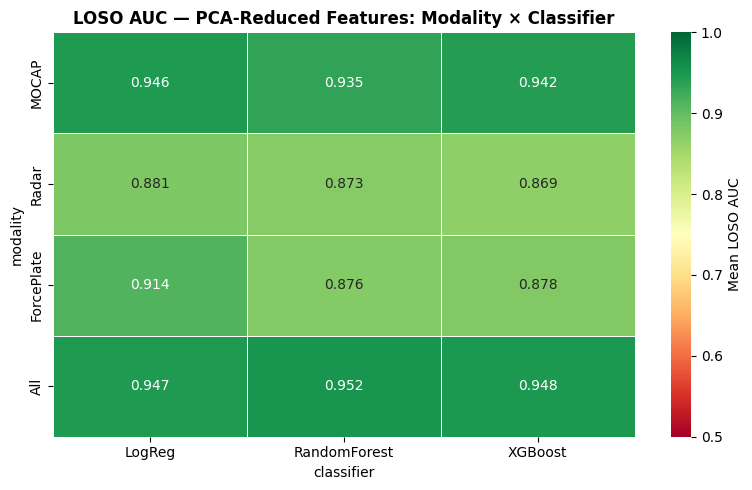

In [19]:
# Heatmap — PCA results
pivot_pca = (df_res_pca
             .assign(modality=df_res_pca['modality_base'])
             .pivot(index='modality', columns='classifier', values='AUC_mean')
             .reindex(mod_order))
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_pca, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Mean LOSO AUC'}, ax=ax)
ax.set_title('LOSO AUC — PCA-Reduced Features: Modality × Classifier', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('loso_auc_heatmap_pca.png', dpi=120, bbox_inches='tight'); plt.show()


## 7 · Feature importance + Top-N selection + ML (LOSO)
RandomForest (on full data) provides Gini + permutation importance.
Top-N features are then used in the same LOSO pipeline for a fair comparison.


In [20]:
# ─── Feature importance: RF on full data ─────────────────────────────────────
print("="*60)
print("FEATURE IMPORTANCE — RandomForest (full data, all features)")
print("="*60)

X_all_sc = StandardScaler().fit_transform(
    df[all_feature_cols].fillna(df[all_feature_cols].median()).values.astype(float))

rf_full = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  max_depth=8, random_state=42, n_jobs=-1)
rf_full.fit(X_all_sc, y)

imp_df = pd.DataFrame({
    'feature':  all_feature_cols,
    'source':   [c.split('_')[0] for c in all_feature_cols],
    'gini_imp': rf_full.feature_importances_,
})

perm = permutation_importance(rf_full, X_all_sc, y, n_repeats=20,
                               random_state=42, n_jobs=-1)
imp_df['perm_imp_mean'] = perm.importances_mean
imp_df['perm_imp_std']  = perm.importances_std
imp_df = imp_df.sort_values('perm_imp_mean', ascending=False).reset_index(drop=True)

print("\nTop 20 features (permutation importance):")
print(imp_df[['feature','source','perm_imp_mean','perm_imp_std','gini_imp']].head(20).to_string(index=False))


FEATURE IMPORTANCE — RandomForest (full data, all features)

Top 20 features (permutation importance):
                             feature     source  perm_imp_mean  perm_imp_std  gini_imp
          MOCAP_lifted_knee_vel_mean      MOCAP       0.069526      0.004894  0.148642
           MOCAP_stance_knee_vel_std      MOCAP       0.001471      0.000712  0.007692
          RADAR_amp_total_power_mean      RADAR       0.001471      0.000327  0.007292
          MOCAP_stance_knee_acc_mean      MOCAP       0.001225      0.000483  0.009978
         RADAR_doppler_centroid_mean      RADAR       0.000940      0.000593  0.005547
                   MOCAP_com_vel_std      MOCAP       0.000899      0.000813  0.005541
           MOCAP_stance_knee_vel_max      MOCAP       0.000858      0.000875  0.009514
           MOCAP_stance_knee_acc_std      MOCAP       0.000694      0.000292  0.005901
           RADAR_amp_peak_power_mean      RADAR       0.000654      0.000327  0.007727
           MOCAP_stance_kne

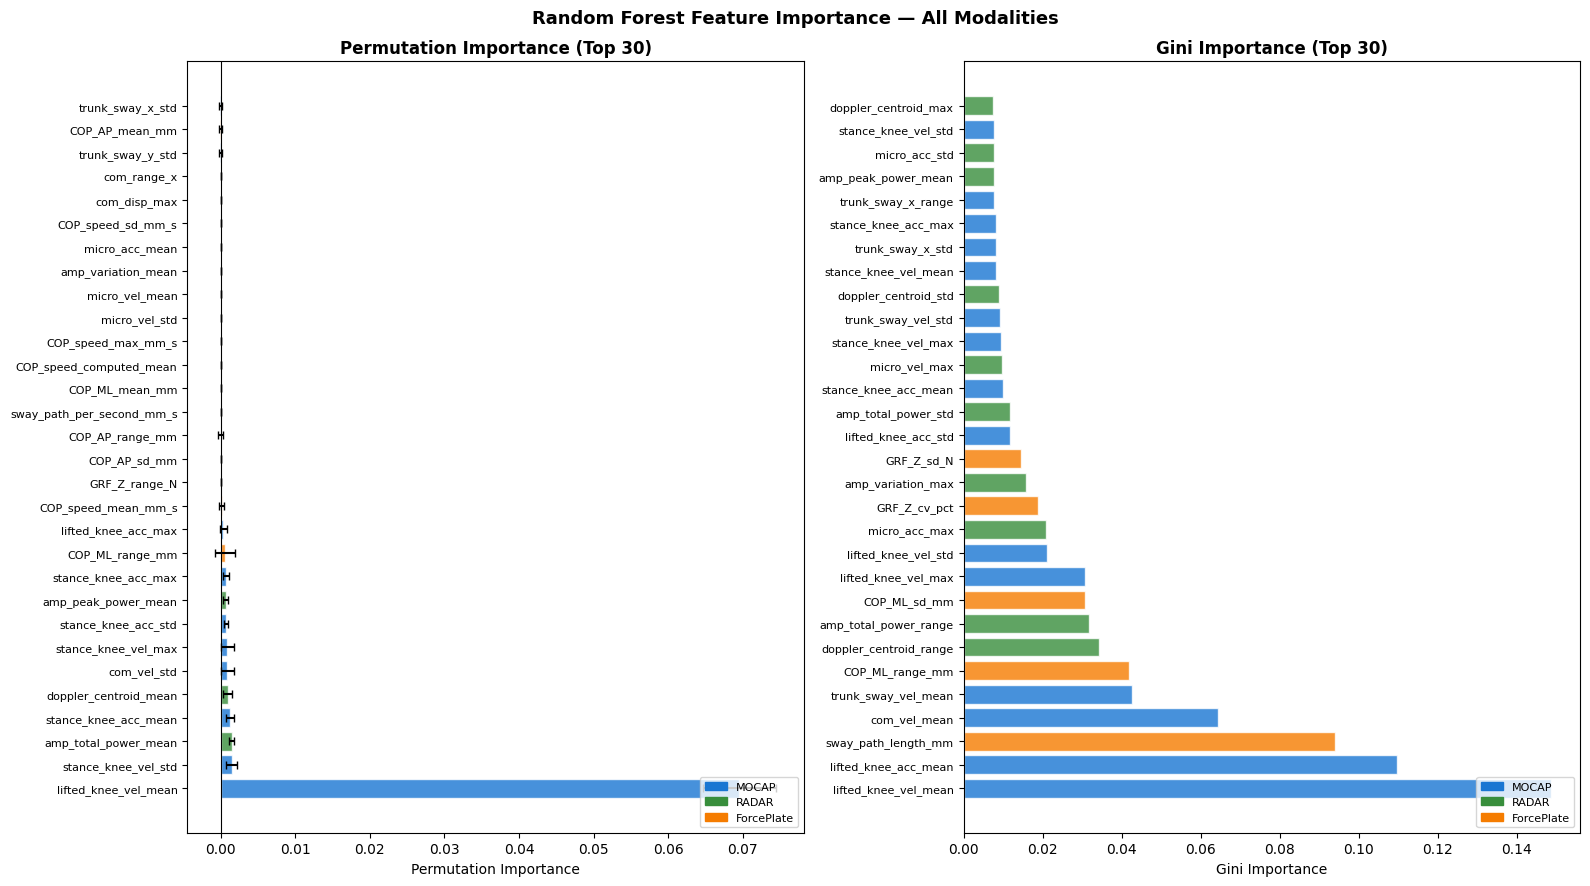

In [21]:
# Plot: Permutation + Gini importance
top30 = imp_df.head(30)
top30g = imp_df.sort_values('gini_imp', ascending=False).head(30)
src_colors_imp = {'MOCAP':'#1976D2','RADAR':'#388E3C','ForcePlate':'#F57C00'}

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

ax = axes[0]
colors_ = [src_colors_imp.get(s,'grey') for s in top30['source']]
ax.barh(range(len(top30)), top30['perm_imp_mean'], xerr=top30['perm_imp_std'],
        color=colors_, alpha=0.8, edgecolor='white', capsize=3)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([c.split('_',1)[1] for c in top30['feature']], fontsize=8)
ax.set_xlabel('Permutation Importance'); ax.set_title('Permutation Importance (Top 30)', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

ax = axes[1]
colors_g = [src_colors_imp.get(s,'grey') for s in top30g['source']]
ax.barh(range(len(top30g)), top30g['gini_imp'], color=colors_g, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top30g)))
ax.set_yticklabels([c.split('_',1)[1] for c in top30g['feature']], fontsize=8)
ax.set_xlabel('Gini Importance'); ax.set_title('Gini Importance (Top 30)', fontweight='bold')

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in src_colors_imp.items()]
for ax in axes:
    ax.legend(handles=legend_handles, fontsize=8, loc='lower right')
plt.suptitle('Random Forest Feature Importance — All Modalities', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('feature_importance_rf.png', dpi=120, bbox_inches='tight'); plt.show()


In [22]:
# ─── Per-modality top-N feature selection ───────────────────────────────────
# For each modality, train a RF on just those features and pick the top N
# by permutation importance within that modality's feature space.

TOP_N = 5   # <-- adjust as needed; 5 is a good starting point

selected_features = {}
print(f"Top-{TOP_N} features selected per modality:\n")

for mod_name, feat_cols in modalities.items():
    X_mod_sc = StandardScaler().fit_transform(
        df[feat_cols].fillna(df[feat_cols].median()).values.astype(float))
    rf_mod = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                     max_depth=6, random_state=42, n_jobs=-1)
    rf_mod.fit(X_mod_sc, y)
    perm_mod = permutation_importance(rf_mod, X_mod_sc, y, n_repeats=15,
                                       random_state=42, n_jobs=-1)
    order = np.argsort(perm_mod.importances_mean)[::-1]
    top_n_cols = [feat_cols[i] for i in order[:TOP_N]]
    selected_features[mod_name] = top_n_cols
    print(f"  {mod_name}:")
    for f in top_n_cols:
        print(f"    {f}")
    print()


Top-5 features selected per modality:

  MOCAP:
    MOCAP_lifted_knee_vel_mean
    MOCAP_com_vel_std
    MOCAP_lifted_knee_acc_max
    MOCAP_lifted_knee_vel_std
    MOCAP_stance_knee_vel_max

  Radar:
    RADAR_micro_acc_mean
    RADAR_amp_variation_mean
    RADAR_doppler_centroid_mean
    RADAR_amp_total_power_mean
    RADAR_micro_acc_std

  ForcePlate:
    ForcePlate_sway_path_length_mm
    ForcePlate_GRF_Z_cv_pct
    ForcePlate_GRF_Z_sd_N
    ForcePlate_COP_AP_mean_mm
    ForcePlate_COP_AP_sd_mm

  All:
    MOCAP_com_vel_std
    MOCAP_lifted_knee_vel_mean
    MOCAP_stance_knee_acc_mean
    RADAR_micro_acc_std
    MOCAP_stance_knee_acc_std



In [23]:
# ─── Run LOSO — Top-N important features ─────────────────────────────────────
print("="*65)
print(f"LOSO — TOP-{TOP_N} IMPORTANT FEATURES PER MODALITY")
print("="*65)

results_topn = []
roc_data_topn = {}

for mod_name, feat_cols in selected_features.items():
    X_mod = df[feat_cols].values.astype(float)
    for clf_name, clf in classifiers.items():
        print(f"  {mod_name:12s} (top-{TOP_N}) | {clf_name:15s}", end=" ... ")
        summary, fd, yt, yp, yprob = loso_evaluate(
            X_mod.copy(), y.copy(), participants.copy(),
            clf=clf, clf_name=clf_name,
            modality_name=f'{mod_name}_Top{TOP_N}',
            scale=True, use_pca=False,
        )
        summary['approach'] = f'Top-{TOP_N}'
        summary['modality_base'] = mod_name
        results_topn.append(summary)
        if clf_name == 'XGBoost':
            fpr, tpr, _ = roc_curve(yt, yprob)
            roc_data_topn[mod_name] = (fpr, tpr, summary['AUC_pooled'])
        print(f"AUC={summary['AUC_mean']:.3f}±{summary['AUC_std']:.3f}  "
              f"F1={summary['F1_mean']:.3f}  BAC={summary['BAC_mean']:.3f}")

df_res_topn = pd.DataFrame(results_topn)
print("\nTop-N results:")
print(df_res_topn[['modality','classifier','AUC_mean','AUC_std','F1_mean']].to_string(index=False))


LOSO — TOP-5 IMPORTANT FEATURES PER MODALITY
AUC=0.958±0.071  F1=0.795  BAC=0.904     ... 
AUC=0.961±0.052  F1=0.768  BAC=0.883t    ... 
AUC=0.957±0.052  F1=0.767  BAC=0.885     ... 
AUC=0.657±0.155  F1=0.336  BAC=0.659     ... 
AUC=0.821±0.082  F1=0.337  BAC=0.610t    ... 
AUC=0.777±0.107  F1=0.398  BAC=0.671     ... 
AUC=0.900±0.100  F1=0.516  BAC=0.819     ... 
AUC=0.909±0.099  F1=0.599  BAC=0.802t    ... 
AUC=0.909±0.097  F1=0.579  BAC=0.793     ... 
AUC=0.960±0.054  F1=0.769  BAC=0.895     ... 
AUC=0.954±0.060  F1=0.783  BAC=0.886t    ... 
AUC=0.944±0.077  F1=0.714  BAC=0.848     ... 

Top-N results:
       modality   classifier  AUC_mean  AUC_std  F1_mean
     MOCAP_Top5       LogReg  0.957809 0.071132 0.794603
     MOCAP_Top5 RandomForest  0.960592 0.052156 0.767942
     MOCAP_Top5      XGBoost  0.956736 0.052061 0.766504
     Radar_Top5       LogReg  0.657357 0.155121 0.335824
     Radar_Top5 RandomForest  0.820605 0.082104 0.337110
     Radar_Top5      XGBoost  0.777163 0.1073

## 8 · Comparison: All features vs PCA vs Top-N important features
Side-by-side summary across all three approaches for each modality and classifier.


In [24]:
# ─── Combine all results into one DataFrame ──────────────────────────────────
def normalise_modality(df_in):
    """Strip suffixes like _PCA5 or _Top5 back to base modality name."""
    df_out = df_in.copy()
    if 'modality_base' in df_out.columns:
        df_out['modality'] = df_out['modality_base']
    else:
        df_out['modality'] = (df_out['modality']
                               .str.replace(r'_PCA\d+', '', regex=True)
                               .str.replace(r'_Top\d+', '', regex=True))
    return df_out

combined = pd.concat([
    normalise_modality(df_res_all),
    normalise_modality(df_res_pca),
    normalise_modality(df_res_topn),
], ignore_index=True)

# Summary pivot: approach × modality for XGBoost
pivot_xgb = (combined[combined['classifier']=='XGBoost']
             .pivot(index='modality', columns='approach', values='AUC_mean')
             .reindex(mod_order))

print("="*70)
print("COMPARISON SUMMARY — XGBoost LOSO AUC (mean across folds)")
print("="*70)
print(pivot_xgb.to_string())
print()
print("(Higher is better; All features = baseline)")


COMPARISON SUMMARY — XGBoost LOSO AUC (mean across folds)
approach    All features       PCA     Top-5
modality                                    
MOCAP           0.965731  0.942179  0.956736
Radar           0.878938  0.868738  0.777163
ForcePlate      0.913363  0.877961  0.909263
All             0.960792  0.948109  0.944129

(Higher is better; All features = baseline)


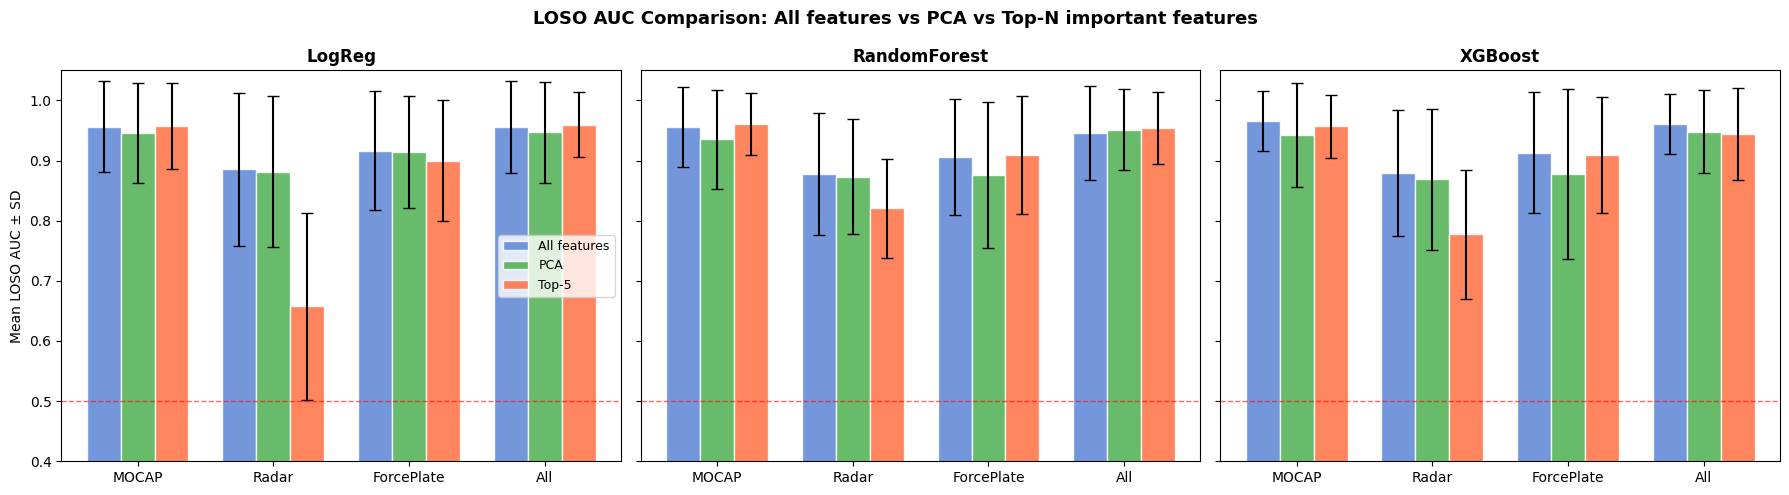

Saved: comparison_all_vs_pca_vs_topn.png


In [25]:
# ─── Side-by-side bar chart ────────────────────────────────────────────────
approach_order  = ['All features', 'PCA', f'Top-{TOP_N}']
approach_colors = ['#5C85D6', '#4CAF50', '#FF7043']

fig, axes = plt.subplots(1, len(classifiers), figsize=(18, 5), sharey=True)

for ax, clf_name in zip(axes, classifiers.keys()):
    sub = combined[combined['classifier'] == clf_name]
    x = np.arange(len(mod_order)); width = 0.25
    for i, (app, color) in enumerate(zip(approach_order, approach_colors)):
        vals = sub[sub['approach']==app].set_index('modality').reindex(mod_order)
        ax.bar(x + i*width, vals['AUC_mean'], width,
               yerr=vals['AUC_std'], capsize=4,
               color=color, alpha=0.85, label=app, edgecolor='white')
    ax.set_xticks(x + width); ax.set_xticklabels(mod_order, fontsize=10)
    ax.set_ylim(0.4, 1.05)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(clf_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean LOSO AUC ± SD' if ax == axes[0] else '')
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.suptitle('LOSO AUC Comparison: All features vs PCA vs Top-N important features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_all_vs_pca_vs_topn.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: comparison_all_vs_pca_vs_topn.png")


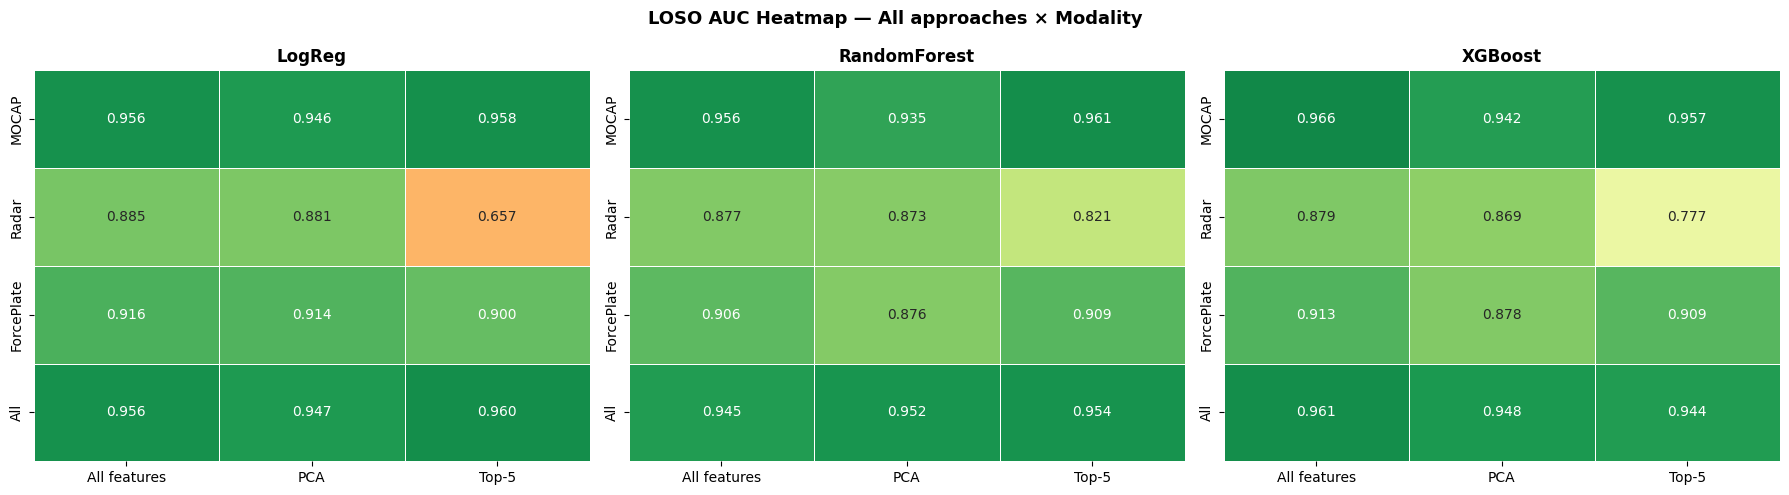

Saved: comparison_heatmap.png


In [26]:
# ─── Approach comparison heatmaps (one per classifier) ──────────────────────
fig, axes = plt.subplots(1, len(classifiers), figsize=(18, 5))

for ax, clf_name in zip(axes, classifiers.keys()):
    sub = combined[combined['classifier'] == clf_name]
    piv = sub.pivot(index='modality', columns='approach', values='AUC_mean')
    piv = piv.reindex(index=mod_order, columns=approach_order)
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.5, vmax=1.0, linewidths=0.5, linecolor='white',
                cbar=False, ax=ax)
    ax.set_title(clf_name, fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('LOSO AUC Heatmap — All approaches × Modality',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: comparison_heatmap.png")


In [28]:
# ─── Final summary table ──────────────────────────────────────────────────────
print("="*80)
print("FINAL SUMMARY — Best AUC per Modality × Approach (across all classifiers)")
print("="*80)

best = (combined.groupby(['modality','approach'])
        .apply(lambda g: g.loc[g['AUC_mean'].idxmax(),
                               ['classifier','AUC_mean','AUC_std','F1_mean','BAC_mean']])
        .reset_index())

best = best.sort_values(['modality','AUC_mean'], ascending=[True, False])
print(best.to_string(index=False))


FINAL SUMMARY — Best AUC per Modality × Approach (across all classifiers)
  modality     approach   classifier  AUC_mean  AUC_std  F1_mean  BAC_mean
       All All features      XGBoost  0.960792 0.050407 0.745253  0.867905
       All        Top-5       LogReg  0.959690 0.053957 0.768763  0.894588
       All          PCA RandomForest  0.951616 0.068079 0.710173  0.831460
ForcePlate All features       LogReg  0.916247 0.098662 0.596230  0.835247
ForcePlate          PCA       LogReg  0.913993 0.093551 0.558544  0.826540
ForcePlate        Top-5      XGBoost  0.909263 0.096658 0.579097  0.792584
     MOCAP All features      XGBoost  0.965731 0.050666 0.795418  0.887576
     MOCAP        Top-5 RandomForest  0.960592 0.052156 0.767942  0.882642
     MOCAP          PCA       LogReg  0.946194 0.082969 0.679005  0.873518
     Radar All features       LogReg  0.885295 0.126899 0.504015  0.799950
     Radar          PCA       LogReg  0.881295 0.125580 0.501515  0.798646
     Radar        Top-5 Ra